# Astrometry : to calculate a distortion solution relative to SN3
### Sébastien Vicens 2025

In [ ]:
## pour convertir un cube hdf5 en fits : 
## dans un terminal et dans orb3 : orb-convert nom.hdf5

In [1]:
import orb as orb
from orcs.process import SpectralCube
import logging
import json

import numpy as np
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
from lmfit import minimize, Parameters

from astropy.io import fits
from astropy.table import QTable
from astropy.table import Table

from astropy.modeling import models, fitting
from IPython.utils import io

from IPython.display import clear_output
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from scipy.spatial import distance
from scipy.ndimage import map_coordinates
from skimage.transform import AffineTransform, warp

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### Data

In [2]:
def read_cube(data_paths_dict, cube_key):
    print(f'{cube_key}:')
    file = data_paths_dict[cube_key]
    cube = SpectralCube(file , verbose=False)
    hdrcube = cube.get_header()
    print(f'Reading: {file}, {cube.shape} \n \n')
    wcs = cube.get_wcs()
    deepframe = cube.get_deep_frame()
    print( hdrcube['DATE'] )
    return cube, hdrcube, deepframe, wcs

def plot_deep_frame_and_histogram(deep_frame, title):
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
   
   # Affichage du deep frame
   fig1 = ax1.imshow(deep_frame, vmin=np.nanpercentile(deep_frame, 10), vmax=np.nanpercentile(deep_frame, 99), origin='lower', cmap='rainbow')
   plt.colorbar(fig1, ax=ax1)
   ax1.set_title(title, size=20)
    
   # Affichage de l'histogramme
   ax2.hist(deep_frame.ravel(), 50, range=(np.nanpercentile(deep_frame, 1), np.nanpercentile(deep_frame, 96)), color='palevioletred')
   plt.show()

def edit_json(filepath, variable_name, variable_value):
    # Open json
    with open(filepath, 'r') as file: data = json.load(file)
    # declare
    data[variable_name] = variable_value
    # Write json
    with open(filepath, 'w') as file: json.dump(data, file, indent=4)
    print(variable_name,' = ',variable_value,' writen into json')
    return


##############


jsonfile = '../data.json'
data_paths_dict = json.load(open(jsonfile))

cube_SN1, hdr_SN1, deep_frame_SN1, wcs_SN1 = read_cube(data_paths_dict, 'cube_SN1')
cube_SN2, hdr_SN2, deep_frame_SN2, wcs_SN2 = read_cube(data_paths_dict, 'cube_SN2')
cube_SN3, hdr_SN3, deep_frame_SN3, wcs_SN3 = read_cube(data_paths_dict, 'cube_SN3')

deep_frame_SN1 = deep_frame_SN1.data.T
deep_frame_SN2 = deep_frame_SN2.data.T
deep_frame_SN3 = deep_frame_SN3.data.T

# Remove bright emission regions from data - to have a good contrast for stars
flux_ha = fits.getdata(data_paths_dict['flux_Halpha'])

#use ha to cut the edge
flux_ha[0:300,:] = np.nan
flux_ha[1900:2064,:] = np.nan
flux_ha[:,0:300] = np.nan
flux_ha[:,1800:2048] = np.nan

flux_ha[np.isnan(flux_ha)] = 0
flux_ha = gaussian_filter(flux_ha, 15)



unknown|INFO| Cube is level 3
unknown|INFO| shape: (2048, 2064, 172)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True
unknown|INFO| Cube is level 3
unknown|INFO| shape: (2048, 2064, 219)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


cube_SN1:
Reading: /users/carmellerobert/Desktop/NGC4490/0-DATA/NGC4490_SN1.merged.cm1.1.0.hdf5, (2048, 2064, 172) 
 

2021-12-31
cube_SN2:
Reading: /users/carmellerobert/Desktop/NGC4490/0-DATA/NGC4490_SN2.merged.cm1.1.0.hdf5, (2048, 2064, 219) 
 



unknown|INFO| Cube is level 3
unknown|INFO| shape: (2048, 2064, 842)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


2021-12-31
cube_SN3:
Reading: /users/carmellerobert/Desktop/NGC4490/0-DATA/NGC4490_SN3.merged.cm1.1.0.hdf5, (2048, 2064, 842) 
 

2022-04-04


In [3]:
hdr_SN1

BITPIX  =                  -32                                                  
CDELT1  =                  1.0                                                  
CDELT2  =                  1.0                                                  
CRPIX1  =               1073.5                                                  
CRPIX2  =               1031.5                                                  
CRVAL1  =      187.64911329088                                                  
CRVAL2  =      41.651783885386                                                  
CTYPE1  = 'RA---TAN-SIP'                                                        
CTYPE2  = 'DEC--TAN-SIP'                                                        
CUNIT1  = 'deg     '                                                            
CUNIT2  = 'deg     '                                                            
DATE    = '2021-12-31'                                                          
EQUINOX =               2000

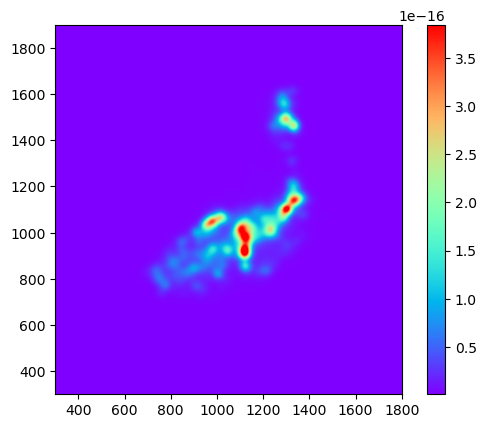

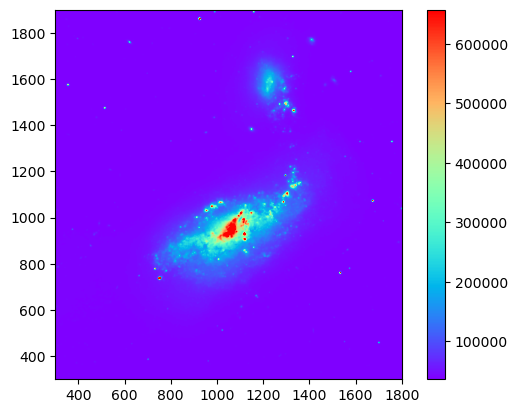

In [4]:
#deep_o = fits.getdata('/users/carmellerobert/Desktop/NGC4490/0-DATA-old+seb/NGC4490_SN3Deep.fits')

xi3,xf3,yi3,yf3 = 300,1800,300,1900
plt.axis([xi3,xf3,yi3,yf3])
vvi = flux_ha[yi3:yf3,xi3:xf3]
plt.imshow(flux_ha, origin='lower',cmap='rainbow', 
           vmin=np.nanpercentile(vvi, 1),vmax=np.nanpercentile(vvi, 99.9))
plt.colorbar()
plt.show()
plt.axis([xi3,xf3,yi3,yf3])
vvi = deep_frame_SN3[yi3:yf3,xi3:xf3]
plt.imshow(deep_frame_SN3, origin='lower',cmap='rainbow', 
           vmin=np.nanpercentile(vvi, 1),vmax=np.nanpercentile(vvi, 99.9))
plt.colorbar()
plt.show()

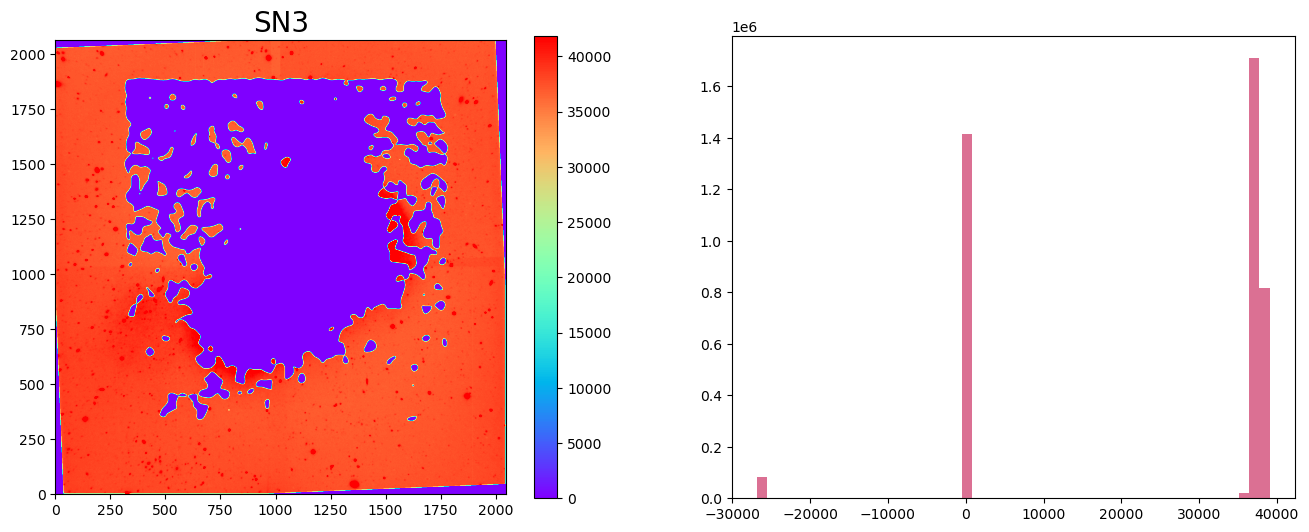

In [5]:
#To mask the bright part of the galaxy : select a limit using Ha flux

limit = 1.12e-18

deep_frame_SN1_detection = np.copy(deep_frame_SN1)
deep_frame_SN2_detection = np.copy(deep_frame_SN2) 
deep_frame_SN3_detection = np.copy(deep_frame_SN3)

#Use Ha to cut galaxy
cond = np.where(np.abs(flux_ha) > limit)  

deep_frame_SN1_detection[cond] = 0
deep_frame_SN2_detection[cond] = 0
deep_frame_SN3_detection[cond] = 0

deep_frame_SN1_detection[np.isnan(deep_frame_SN1_detection)] = 0
deep_frame_SN2_detection[np.isnan(deep_frame_SN2_detection)] = 0
deep_frame_SN3_detection[np.isnan(deep_frame_SN3_detection)] = 0

deep_frames = {'SN1' : deep_frame_SN1,  'SN2' : deep_frame_SN2, 'SN3' : deep_frame_SN3 }

### Have a look
plot_deep_frame_and_histogram(deep_frame_SN3_detection, 'SN3')

# DETECTION OF STARS  IN THE THREE CUBES 

In [6]:
# Function to detect stars in an image

def detect_stars(image, threshold_factor, fwhm_pixels, title):
    """
    Detects stars in an image using the DAOStarFinder method.
    
    Parameters:
        image (numpy array): The image in which to detect stars.
        threshold_factor (float): Factor to calculate the detection threshold (threshold = factor * std).
        fwhm_pixels (float): Full Width at Half Maximum (FWHM) of the stars in pixels.
        title (str): Title of the image (for display purposes).
    
    Returns:
        stars (Table): Table of detected stars.
    """
    # Calculate image statistics using sigma clipping
    mean, median, std = sigma_clipped_stats(image, sigma=3.0)
    
    # Define the detection threshold based on the standard deviation and threshold factor
    threshold = threshold_factor * std
    
    # Initialize the DAOStarFinder with FWHM and threshold parameters
    star_finder = DAOStarFinder(fwhm=fwhm_pixels, threshold=threshold)  
    
    # Apply the star detection to the image
    stars = star_finder(image)  
    
    # Get the positions of detected stars
    positions = np.transpose((stars['xcentroid'], stars['ycentroid']))
    
    # Create circular apertures around detected stars (for later display)
    apertures = CircularAperture(positions, r=3.)
    
    # Normalize the image for display purposes
    norm = ImageNormalize(stretch=SqrtStretch())
    
    # Display detection information
    print(f"{title}: Threshold = {threshold}, FWHM = {fwhm_pixels}, Number of stars found = {len(stars['id'])}")
    
    return stars


def match_stars(stars_SN3, stars_other, match_radius):
    """
    Matches stars between the SN3 image and another image based on their positions.
    
    Parameters:
        stars_SN3 (Table): Table of stars detected in the SN3 image.
        stars_other (Table): Table of stars detected in another image (SN1 or SN2).
        match_radius (float): The maximum distance (in pixels) to consider two stars a match.
        
    Returns:
        matched_indices_SN3 (list): Indices of matched stars in SN3.
        matched_indices_other (list): Indices of matched stars in the other image.
    """
    # Extract positions of stars in SN3 and the other image
    positions_SN3   = np.transpose((stars_SN3['xcentroid'], stars_SN3['ycentroid']))
    positions_other = np.transpose((stars_other['xcentroid'], stars_other['ycentroid']))
    
    # Build a KD-Tree for fast spatial matching
    tree_SN3 = cKDTree(positions_SN3)
    
    # Query the KD-Tree with the positions from the other image to find matches
    distances, indices = tree_SN3.query(positions_other, distance_upper_bound=match_radius)
    
    # Filter out invalid matches (those where no match was found within the radius)
    valid_matches = np.isfinite(distances)
    
    # Get the matched indices
    matched_indices_SN3 = indices[valid_matches]
    matched_indices_other = np.where(valid_matches)[0]
    
    return matched_indices_SN3, matched_indices_other

def match_stars_sn3_sn2_sn1(stars_SN3, stars_SN2, stars_SN1, match_radius):
    """
    Matches stars detected in SN3 and SN2, then uses the matched SN2 stars to match with SN1.
    
    Parameters:
        stars_SN3 (Table): Table of stars detected in the SN3 image.
        stars_SN2 (Table): Table of stars detected in the SN2 image.
        stars_SN1 (Table): Table of stars detected in the SN1 image.
        match_radius (float): The maximum distance (in pixels) to consider two stars a match.
        
    Returns:
        matched_SN3 (Table): Stars from SN3 that have matches in both SN2 and SN1.
        matched_SN2 (Table): Matched stars from SN2 that match with both SN3 and SN1.
        matched_SN1 (Table): Matched stars from SN1.
    """
    # Step 1: Match stars between SN3 and SN2
    matched_SN3_SN2_indices, matched_SN2_indices = match_stars(stars_SN3, stars_SN2, match_radius)
    
    # Get the corresponding stars in SN2 for the matched indices
    matched_SN2 = stars_SN2[matched_SN2_indices]
    
    # Step 2: Match the matched stars from SN2 with SN1
    matched_SN2_SN1_indices, matched_SN1_indices = match_stars(matched_SN2, stars_SN1, match_radius)
    
    # Since the SN2 stars are matched with SN1, we need to trace back the corresponding SN3 stars
    matched_SN3_final = stars_SN3[matched_SN3_SN2_indices[matched_SN2_SN1_indices]]  # Keep only those SN3 stars that match with both SN2 and SN1
    matched_SN2_final = matched_SN2[matched_SN2_SN1_indices]
    matched_SN1_final = stars_SN1[matched_SN1_indices]
    
    return matched_SN3_final, matched_SN2_final, matched_SN1_final

def assign_new_ids(matched_SN3, matched_SN2, matched_SN1):
    """
    Assigns new IDs starting from 1 to matched stars in all three tables (SN3, SN2, and SN1).
    
    Parameters:
        matched_SN3 (Table): Matched stars from SN3.
        matched_SN2 (Table): Matched stars from SN2.
        matched_SN1 (Table): Matched stars from SN1.
        
    Returns:
        matched_SN3 (Table): Stars from SN3 with new IDs.
        matched_SN2 (Table): Stars from SN2 with new IDs.
        matched_SN1 (Table): Stars from SN1 with new IDs.
    """
    # Create a new 'id' column with values starting from 1
    new_ids = np.arange(1, len(matched_SN3) + 1)
    
    # Assign new IDs to each table
    matched_SN3['id'] = new_ids
    matched_SN2['id'] = new_ids
    matched_SN1['id'] = new_ids
    
    return matched_SN3, matched_SN2, matched_SN1

In [7]:

# Parameters for star detection (threshold factor and FWHM in pixels):

threshold_factor = 0.09  # The factor for calculating the threshold (threshold = factor * std) : so ~2000 stars in common
fwhm_pixels = 3  # Full Width at Half Maximum (FWHM) of the stars in pixels    ### 3 for CFHT

# Apply star detection on the three images (SN1, SN2, SN3)
daofind_SN3 = detect_stars(deep_frame_SN3_detection, threshold_factor, fwhm_pixels, 'SN3')
daofind_SN2 = detect_stars(deep_frame_SN2_detection, threshold_factor, fwhm_pixels, 'SN2')
daofind_SN1 = detect_stars(deep_frame_SN1_detection, threshold_factor, fwhm_pixels, 'SN1')


### MATCH THE DETECTIONS IN THE THREE CUBES ###

# ************* 
# Define the matching radius (in pixels) : 5 is good in general, too large will associate too many stars

match_radius = 5.0  # Adjust based on your data's precision

# Perform the matching in two steps: SN3 -> SN2 -> SN1
matched_SN3, matched_SN2, matched_SN1 = match_stars_sn3_sn2_sn1(daofind_SN3, daofind_SN2, daofind_SN1, match_radius)

# Assign new sequential IDs starting from 1
daofind_SN3, daofind_SN2, daofind_SN1 = assign_new_ids(matched_SN3, matched_SN2, matched_SN1)

# Output the number of matched stars and their new IDs
print(f"Number of stars matched between SN3, SN2, and SN1: {len(matched_SN3)}")

#cutto=x300-1800 y300-1900 ha<-18    = 1456
#cutto=x300-1800 y300-1900 ha<-17.9  = 1493
#cutto=x300-1800 y300-1900 ha<-17.95  = 1754 !



SN3: Threshold = 1617.5123193601053, FWHM = 3, Number of stars found = 1963
SN2: Threshold = 653.369221439626, FWHM = 3, Number of stars found = 2538
SN1: Threshold = 225.3427699453922, FWHM = 3, Number of stars found = 4284
Number of stars matched between SN3, SN2, and SN1: 1754


In [8]:

# Function to fit a 2D Gaussian to a star with background and dynamic sigma threshold

def fit_gaussian_with_background(data, x0, y0, limit, size=5):
    """
    Fits a 2D Gaussian to a star within a specified region and filters by sigma threshold.
    """
    # Define the fitting region around the star
    y_min = int(max(y0 - size, 0))
    y_max = int(min(y0 + size + 1, data.shape[0]))
    x_min = int(max(x0 - size, 0))
    x_max = int(min(x0 + size + 1, data.shape[1]))
    
    try:
        # Set up grid and data for fitting
        y, x = np.mgrid[y_min:y_max, x_min:x_max]
        z = data[y_min:y_max, x_min:x_max]
        
        # Initialize Gaussian model with background
        gaussian_model = models.Gaussian2D(amplitude=np.max(z), x_mean=x0, y_mean=y0, x_stddev=3, y_stddev=3, theta=0)
        background_model = models.Const2D(amplitude=np.median(z))
        combined_model = gaussian_model + background_model
        
        fit_p = fitting.LevMarLSQFitter()
        p = fit_p(combined_model, x, y, z)
        
        # Apply the sigma threshold filter
        if p.x_stddev_0.value > limit or p.y_stddev_0.value > limit:
            return None  # Return None if it doesn't meet the threshold criteria
        
        # Return a dictionary with the fitted parameters
        return {
            'amplitude': p.amplitude_0.value,
            'x_center': p.x_mean_0.value,
            'y_center': p.y_mean_0.value,
            'sigma_x': p.x_stddev_0.value,
            'sigma_y': p.y_stddev_0.value,
            'theta': p.theta_0.value,
            'background': p.amplitude_1.value
        }
    except (ValueError, IndexError):
        # Return None if fitting region is invalid or fitting fails
        return None



############################

# Define the sigma threshold limit
sigma_limit = 100000.0  # Adjust as needed

# Initialize table for storing results
all_stars_table = Table(
    names=('id', 'xcentroid_SN1', 'ycentroid_SN1', 'xcentroid_SN2', 'ycentroid_SN2', 'xcentroid_SN3', 'ycentroid_SN3',
           'amplitude_SN1', 'x_center_SN1', 'y_center_SN1', 'sigma_x_SN1', 'sigma_y_SN1', 'theta_SN1', 'background_SN1',
           'amplitude_SN2', 'x_center_SN2', 'y_center_SN2', 'sigma_x_SN2', 'sigma_y_SN2', 'theta_SN2', 'background_SN2',
           'amplitude_SN3', 'x_center_SN3', 'y_center_SN3', 'sigma_x_SN3', 'sigma_y_SN3', 'theta_SN3', 'background_SN3'),
    dtype=('int', 'float', 'float', 'float', 'float', 'float', 'float', 
           'float', 'float', 'float', 'float', 'float', 'float', 'float',
           'float', 'float', 'float', 'float', 'float', 'float', 'float',
           'float', 'float', 'float', 'float', 'float', 'float', 'float') )

# Fit stars in each cube (SN1, SN2, SN3) and save all data into one table
for idx, (star_SN3, star_SN2, star_SN1) in enumerate(zip(matched_SN3, matched_SN2, matched_SN1), start=1):
    # Fit each star in SN1, SN2, SN3 images
    fit_SN1 = fit_gaussian_with_background(deep_frame_SN1, star_SN1['xcentroid'], star_SN1['ycentroid'], sigma_limit)
    fit_SN2 = fit_gaussian_with_background(deep_frame_SN2, star_SN2['xcentroid'], star_SN2['ycentroid'], sigma_limit)
    fit_SN3 = fit_gaussian_with_background(deep_frame_SN3, star_SN3['xcentroid'], star_SN3['ycentroid'], sigma_limit)
    
    # Only add to the table if all fits are successful
    if fit_SN1 and fit_SN2 and fit_SN3:
        all_stars_table.add_row([
            idx,
            star_SN1['xcentroid'], star_SN1['ycentroid'],
            star_SN2['xcentroid'], star_SN2['ycentroid'],
            star_SN3['xcentroid'], star_SN3['ycentroid'],
            
            fit_SN1['amplitude'], fit_SN1['x_center'], fit_SN1['y_center'], fit_SN1['sigma_x'], fit_SN1['sigma_y'], fit_SN1['theta'], fit_SN1['background'],
            fit_SN2['amplitude'], fit_SN2['x_center'], fit_SN2['y_center'], fit_SN2['sigma_x'], fit_SN2['sigma_y'], fit_SN2['theta'], fit_SN2['background'],
            fit_SN3['amplitude'], fit_SN3['x_center'], fit_SN3['y_center'], fit_SN3['sigma_x'], fit_SN3['sigma_y'], fit_SN3['theta'], fit_SN3['background']])

# Output the final table with all detected and fitted stars
print(f"Total stars detected and fitted across all cubes: {len(all_stars_table)}")
# all_stars_table.show_in_browser()  # Optionally display table



Total stars detected and fitted across all cubes: 1754


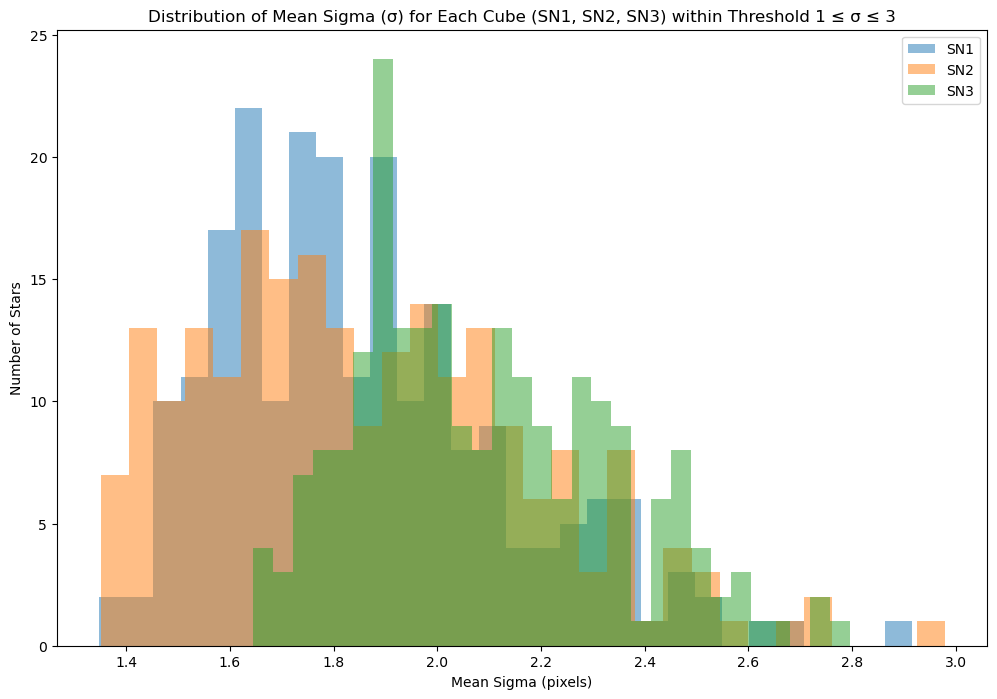

221


In [10]:

# **************
# Define the thresholds for sigma values : first from 0 to 100, 
# then reduce (like 1 to 3) to keep good stars (i.e. with low sigma and more than 200 stars)
sigma_threshold_sup = 3   # Upper threshold
sigma_threshold_inf = 1    # Lower threshold

# Filter the table to keep only rows where sigma_x and sigma_y for all cubes fall within the threshold range
all_stars_table2 = all_stars_table[
    (all_stars_table['sigma_x_SN1'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_y_SN1'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_x_SN1'] >= sigma_threshold_inf) &
    (all_stars_table['sigma_y_SN1'] >= sigma_threshold_inf) &
    (all_stars_table['sigma_x_SN2'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_y_SN2'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_x_SN2'] >= sigma_threshold_inf) &
    (all_stars_table['sigma_y_SN2'] >= sigma_threshold_inf) &
    (all_stars_table['sigma_x_SN3'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_y_SN3'] <= sigma_threshold_sup) &
    (all_stars_table['sigma_x_SN3'] >= sigma_threshold_inf) &
    (all_stars_table['sigma_y_SN3'] >= sigma_threshold_inf) ]

# Calculate the mean sigma for each cube (SN1, SN2, SN3)
mean_sigma_SN1 = (all_stars_table2['sigma_x_SN1'] + all_stars_table2['sigma_y_SN1']) / 2
mean_sigma_SN2 = (all_stars_table2['sigma_x_SN2'] + all_stars_table2['sigma_y_SN2']) / 2
mean_sigma_SN3 = (all_stars_table2['sigma_x_SN3'] + all_stars_table2['sigma_y_SN3']) / 2

# Plot histograms for the mean sigma values for each cube
plt.figure(figsize=(12, 8))

plt.hist(mean_sigma_SN1, bins=30, alpha=0.5, label='SN1')
plt.hist(mean_sigma_SN2, bins=30, alpha=0.5, label='SN2')
plt.hist(mean_sigma_SN3, bins=30, alpha=0.5, label='SN3')

plt.xlabel('Mean Sigma (pixels)')
plt.ylabel('Number of Stars')
plt.title(f'Distribution of Mean Sigma (σ) for Each Cube (SN1, SN2, SN3) within Threshold {sigma_threshold_inf} ≤ σ ≤ {sigma_threshold_sup}')
plt.legend()
plt.show()


print(len(all_stars_table2))


# 1st method based on daofind results
### Will do separatly SN1 and SN2 - you must select which one first here and come back later to do the other

49


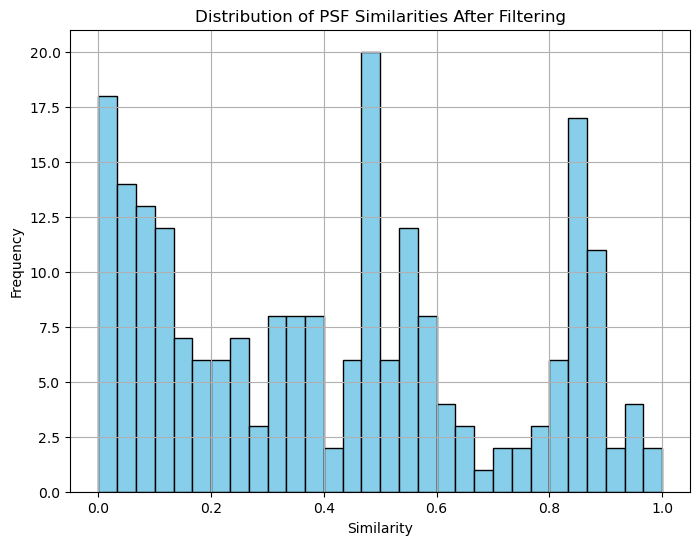

In [16]:

# Function to calculate PSF similarity
def compute_psf_similarity(psf_ref, psf_align):
    sigma_diff = np.sqrt(((psf_ref[:, 0] - psf_align[:, 0]) / psf_ref[:, 0])**2 +
                         ((psf_ref[:, 1] - psf_align[:, 1]) / psf_ref[:, 1])**2)
    theta_diff = np.abs(psf_ref[:, 2] - psf_align[:, 2]) / np.pi
    similarity = 1 / (1 + sigma_diff + theta_diff)
    return similarity


###############

# *********** Select comparison:
sncom = 'SN2'        # 'SN2'


# Load PSF parameters from all_stars_table: reference filter
psf_params_ref = np.vstack((all_stars_table2['sigma_x_SN3'], all_stars_table2['sigma_y_SN3'], all_stars_table2['theta_SN3'])).T

if sncom == 'SN1': 
    psf_params_align = np.vstack((all_stars_table2['sigma_x_SN1'], all_stars_table2['sigma_y_SN1'], all_stars_table2['theta_SN1'])).T
if sncom == 'SN2': 
    psf_params_align = np.vstack((all_stars_table2['sigma_x_SN2'], all_stars_table2['sigma_y_SN2'], all_stars_table2['theta_SN2'])).T

# Compute PSF similarity and normalize
similarity = compute_psf_similarity(psf_params_ref, psf_params_align)
similarity = (similarity - similarity.min()) / (similarity.max() - similarity.min())

# Add similarity as a new column to all_stars_table
all_stars_table2['similarity'] = similarity


# ***************** 
# Set similarity threshold : 
# 0 will take all but see distribution to keep the best at higher threshold with more that 30 remaining stars
similarity_threshold = 0.7  # Adjust this as needed

# Filter the table based on the similarity threshold
all_stars_table3 = all_stars_table2[all_stars_table2['similarity'] >= similarity_threshold]

print(len(all_stars_table3))
# Display the filtered similarity distribution
plt.figure(figsize=(8, 6))
plt.hist(all_stars_table2['similarity'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of PSF Similarities After Filtering')
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



42


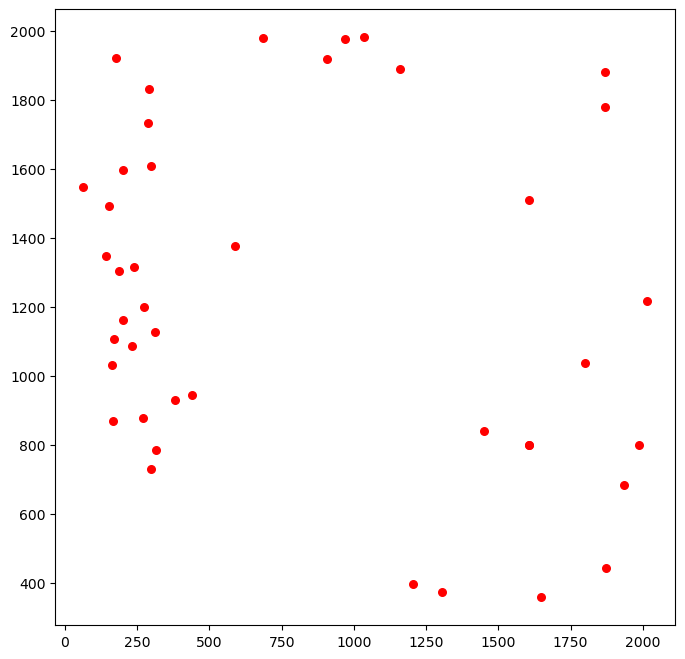

In [17]:

# *************
# Set the minimum allowed distance between stars so too much weight is specific locations
# 50 pixels is a good number, unless less than 30 stars remain
min_distance = 50.0  


# Convert star positions to a 2D array for distance calculations
positions = np.vstack((all_stars_table3['xcentroid_SN3'], all_stars_table3['ycentroid_SN3'])).T
similarities = np.array(all_stars_table3['similarity'])

# Compute pairwise distances
dist_matrix = distance.cdist(positions, positions)

# Find pairs where distance is less than min_distance, ignoring self-pairs (distance=0)
close_pairs = np.argwhere((dist_matrix < min_distance) & (dist_matrix > 0))

# Keep track of stars to remove (those with lower similarity in each close pair)
stars_to_remove = set()

for i, j in close_pairs:
    if similarities[i] > similarities[j]:
        stars_to_remove.add(j)
    else:
        stars_to_remove.add(i)

# Create a filtered table excluding the stars marked for removal
mask = np.ones(len(all_stars_table3), dtype=bool)
mask[list(stars_to_remove)] = False
all_stars_table4 = all_stars_table3[mask]

if sncom == 'SN1': nbstarsn1 = len(all_stars_table4)
if sncom == 'SN2': nbstarsn2 = len(all_stars_table4)   
print(len(all_stars_table4))


def load_star_positions_from_all_stars_table(table, sn_key):
    """
    Loads x and y centroid positions for a given SN frame from the combined all_stars_table.
    """
    x_col = f'xcentroid_{sn_key}'
    y_col = f'ycentroid_{sn_key}'
    return np.vstack((table[x_col], table[y_col])).T


stars_SN3 = load_star_positions_from_all_stars_table(all_stars_table4, 'SN3')

# Display final filtered similarity distribution if needed
plt.figure(figsize=(8, 8))
plt.scatter(stars_SN3[:,0], stars_SN3[:,1], color='red', label='SN3', s=30)

[[1650.28387434  358.03306498]
 [1306.02974701  371.55577547]
 [1204.6719941   395.13913791]
 [1872.42366218  443.12215017]
 [1934.73177963  684.214622  ]
 [ 299.72699281  729.89117142]
 [ 314.53417344  783.95984036]
 [1606.91156974  800.35825055]
 [1986.13933488  800.4556572 ]
 [1606.91156974  800.35825055]
 [1452.54632058  838.38445911]
 [ 166.97794349  868.0802509 ]
 [ 271.52374453  875.87370309]
 [ 382.73136187  929.23330578]
 [ 440.19115648  943.34831357]
 [ 162.84060604 1028.57625035]
 [1800.043802   1036.25187809]
 [ 234.29075322 1084.96190922]
 [ 170.62980684 1104.542964  ]
 [ 311.28325204 1125.6476629 ]
 [ 201.77070231 1159.07128975]
 [ 276.47447218 1199.32612137]
 [2014.86241464 1217.08914704]
 [ 186.8282274  1301.69573954]
 [ 241.24759033 1313.49501901]
 [ 142.62444003 1346.87860382]
 [ 587.9277464  1374.11170155]
 [ 153.97323009 1490.66641952]
 [1607.750818   1508.49138055]
 [  64.92406329 1544.11685351]
 [ 200.07096625 1593.37131579]
 [ 296.61245942 1606.25698791]
 [ 288.6

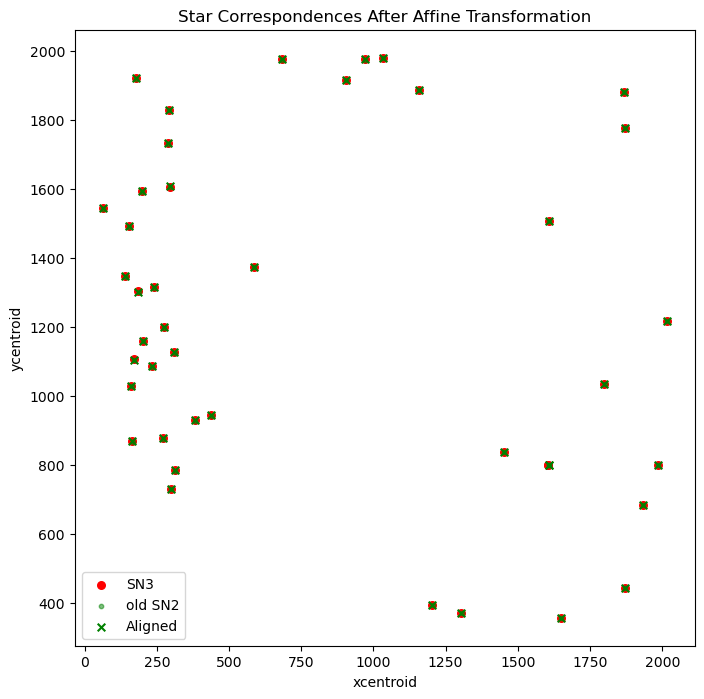

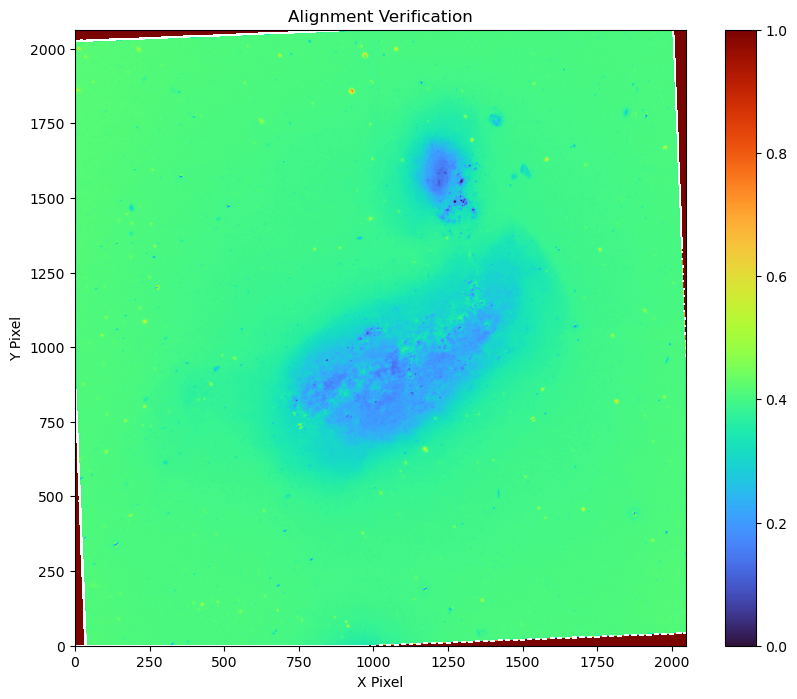

In [18]:


# Load star positions : reference:
stars_SN3 = load_star_positions_from_all_stars_table(all_stars_table4, 'SN3')

# ***************** comparison:
if sncom == 'SN1':
    stars_SNcom      = load_star_positions_from_all_stars_table(all_stars_table4, 'SN1')
    deep_frame_SNcom = np.copy(deep_frame_SN1)
    tit = 'old SN1'
if sncom == 'SN2': 
    stars_SNcom      = load_star_positions_from_all_stars_table(all_stars_table4, 'SN2')
    deep_frame_SNcom = np.copy(deep_frame_SN2)
    tit = 'old SN2'

print(stars_SNcom)
print(stars_SN3)

# Transformation estimation and visualization
affine = AffineTransform()
affine.estimate(stars_SNcom, stars_SN3)
aligned_SNcom = warp(deep_frame_SNcom, inverse_map=affine.inverse, mode='constant', cval=0)
aligned_stars_SNcom = affine(stars_SNcom)

if sncom == 'SN1': SN1_sol1 = affine.params
if sncom == 'SN2': SN2_sol1 = affine.params
print(sncom+' solution 1: ', affine.params )
print()


# Compute and print residuals
residuals = stars_SN3 - aligned_stars_SNcom
residuals_dist = np.sqrt(np.sum(residuals**2, axis=1))
if sncom == 'SN1': SN1_res1,SN1_dist1 = np.mean(residuals_dist), np.max(residuals_dist)
if sncom == 'SN2': SN2_res1,SN2_dist1 = np.mean(residuals_dist), np.max(residuals_dist)
print(f'Mean positional error after alignment: {np.mean(residuals_dist):.3f} pixels')
print(f'Maximum positional error after alignment: {np.max(residuals_dist):.3f} pixels')

# Plotting star correspondences
plt.figure(figsize=(8, 8))
plt.scatter(stars_SN3[:,0], stars_SN3[:,1], color='red', label='SN3', s=30)    
plt.scatter(stars_SNcom[:,0], stars_SNcom[:,1], s=10, label=tit, alpha=0.5, c = 'green')
plt.scatter(aligned_stars_SNcom[:,0], aligned_stars_SNcom[:,1], color='green', marker='x', label='Aligned', s=30)
plt.legend()
plt.title('Star Correspondences After Affine Transformation')
plt.xlabel('xcentroid')
plt.ylabel('ycentroid')
plt.show()

# Verify alignment visually
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(deep_frame_SN3 / aligned_SNcom), origin='lower', cmap='turbo', alpha=1, vmin=0, vmax=1)
plt.title('Alignment Verification')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.colorbar()
plt.show()


# 2nd method based on cumulative profile

<AffineTransform(matrix=
    [[ 1.00053960e+00,  8.63859778e-04, -2.20657967e+00],
     [-8.21618720e-04,  1.00042526e+00,  1.74583204e+00],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])>
SN2 solution 2:  [[ 1.00053960e+00  8.63859778e-04 -2.20657967e+00]
 [-8.21618720e-04  1.00042526e+00  1.74583204e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Mean positional error after alignment: 0.129 pixels
Maximum positional error after alignment: 0.557 pixels


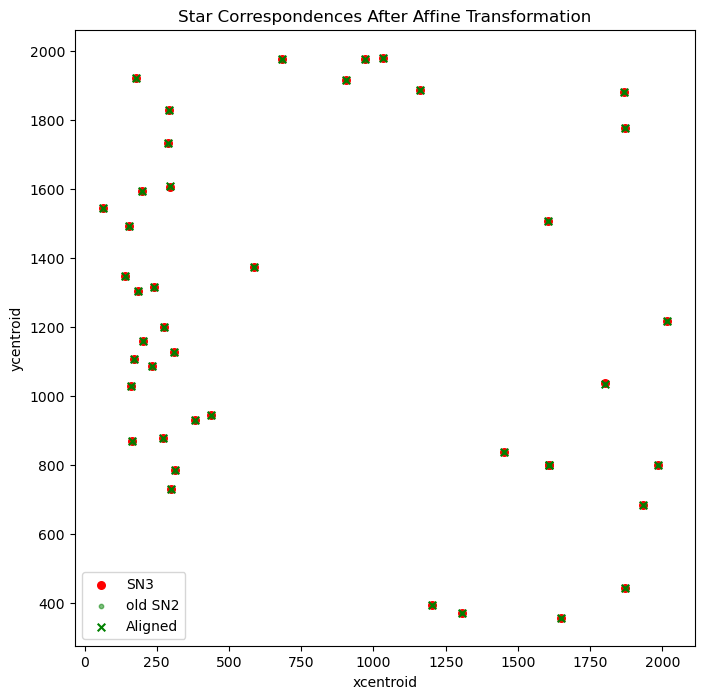

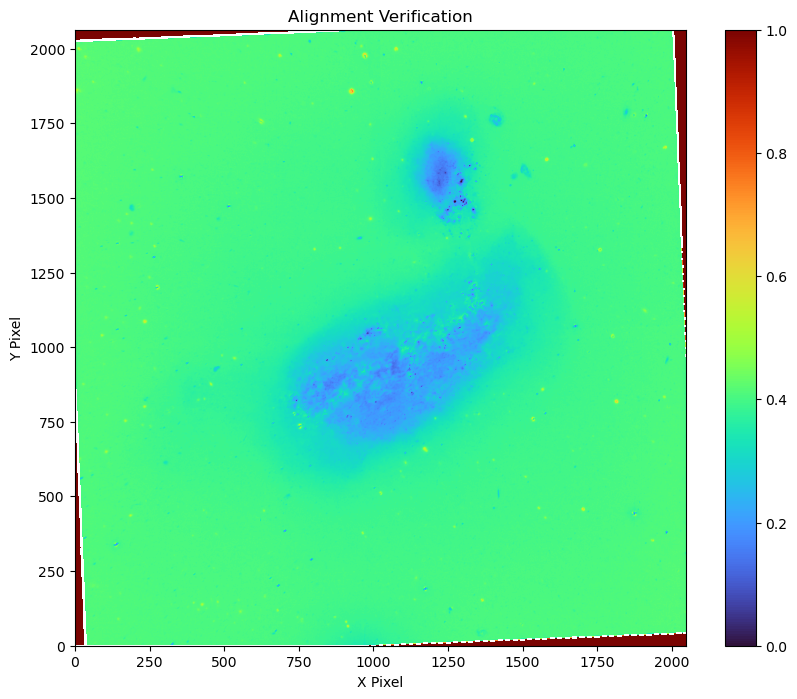

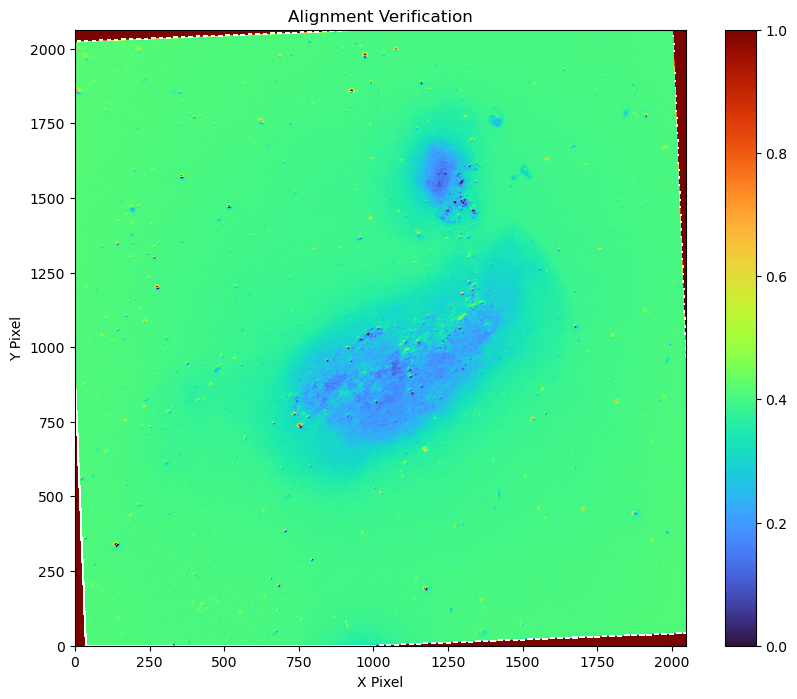

In [19]:
def load_star_positions_from_all_stars_table2(table, sn_key):
    """
    Loads x and y centroid positions for a given SN frame from the combined all_stars_table.
    """
    x_col = f'x_center_{sn_key}'
    y_col = f'y_center_{sn_key}'
    return np.vstack((table[x_col], table[y_col])).T

# Load star positions : reference
stars_SN3 = load_star_positions_from_all_stars_table2(all_stars_table4, 'SN3')

## ... comparison:
if sncom == 'SN1':
    stars_SNcom      = load_star_positions_from_all_stars_table2(all_stars_table4, 'SN1')
    deep_frame_SNcom = np.copy(deep_frame_SN1)
    tit = 'old SN1'
if sncom == 'SN2': 
    stars_SNcom      = load_star_positions_from_all_stars_table2(all_stars_table4, 'SN2')
    deep_frame_SNcom = np.copy(deep_frame_SN2)
    tit = 'old SN2'

# Transformation estimation and visualization
affine = AffineTransform()
affine.estimate(stars_SNcom, stars_SN3)
aligned_SNcom = warp(deep_frame_SNcom, inverse_map=affine.inverse, mode='constant', cval=0)
aligned_stars_SNcom = affine(stars_SNcom)
print(affine)

if sncom == 'SN1': SN1_sol2 = affine.params
if sncom == 'SN2': SN2_sol2 = affine.params
print(sncom+' solution 2: ', affine.params)
print()

# Compute and print residuals
residuals = stars_SN3 - aligned_stars_SNcom
residuals_dist = np.sqrt(np.sum(residuals**2, axis=1))
if sncom == 'SN1': SN1_res2,SN1_dist2 = np.mean(residuals_dist), np.max(residuals_dist)
if sncom == 'SN2': SN2_res2,SN2_dist2 = np.mean(residuals_dist), np.max(residuals_dist)
print(f'Mean positional error after alignment: {np.mean(residuals_dist):.3f} pixels')
print(f'Maximum positional error after alignment: {np.max(residuals_dist):.3f} pixels')


# Plotting star correspondences
plt.figure(figsize=(8, 8))
plt.scatter(stars_SN3[:,0], stars_SN3[:,1], color='red', label='SN3', s=30)    
plt.scatter(stars_SNcom[:,0], stars_SNcom[:,1], s=10, label=tit, alpha=0.5, c = 'green')
plt.scatter(aligned_stars_SNcom[:,0], aligned_stars_SNcom[:,1], color='green', marker='x', label='Aligned', s=30)
plt.legend()
plt.title('Star Correspondences After Affine Transformation')
plt.xlabel('xcentroid')
plt.ylabel('ycentroid')
plt.show()

# Verify alignment visually
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(deep_frame_SN3 / aligned_SNcom), origin='lower', cmap='turbo', alpha=1, vmin=0, vmax=1)
plt.title('Alignment Verification')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.colorbar()

# Verify alignment visually
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(deep_frame_SN3 / deep_frame_SNcom), origin='lower', cmap='turbo', alpha=1, vmin=0, vmax=1)
plt.title('Alignment Verification')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.colorbar()

plt.show()

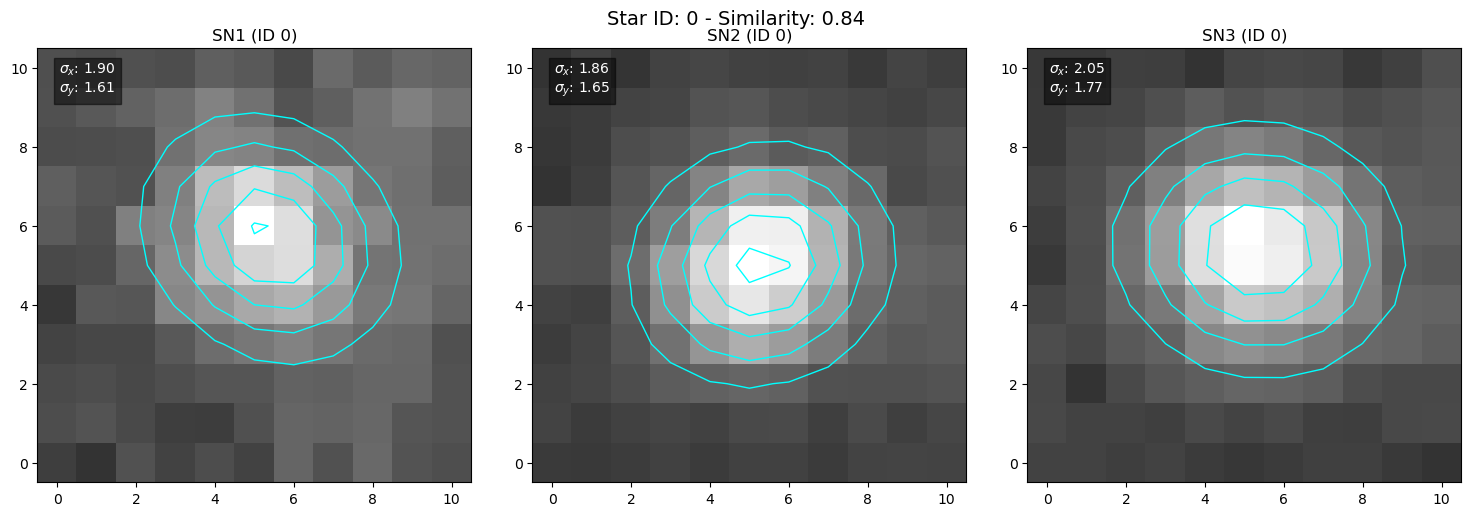

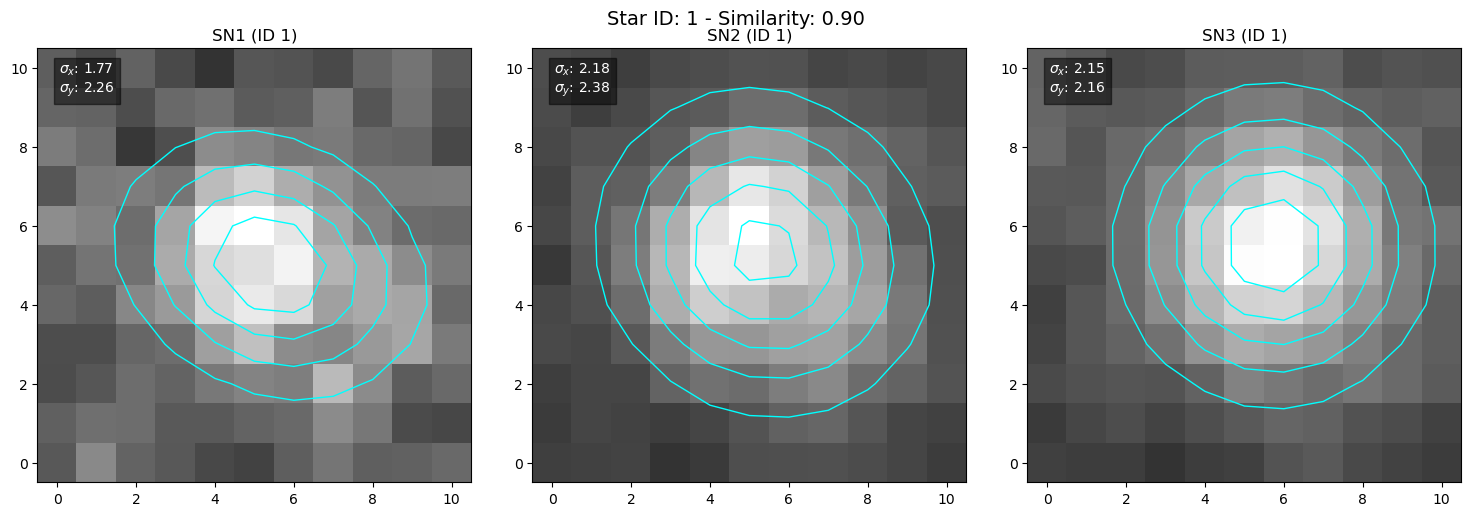

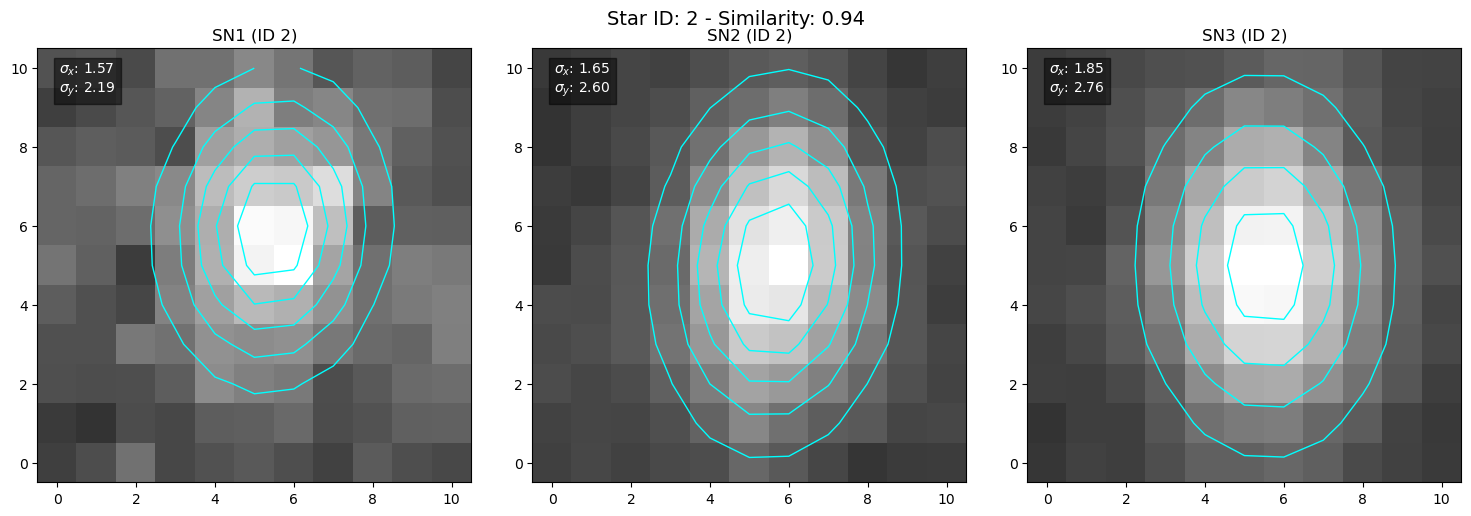

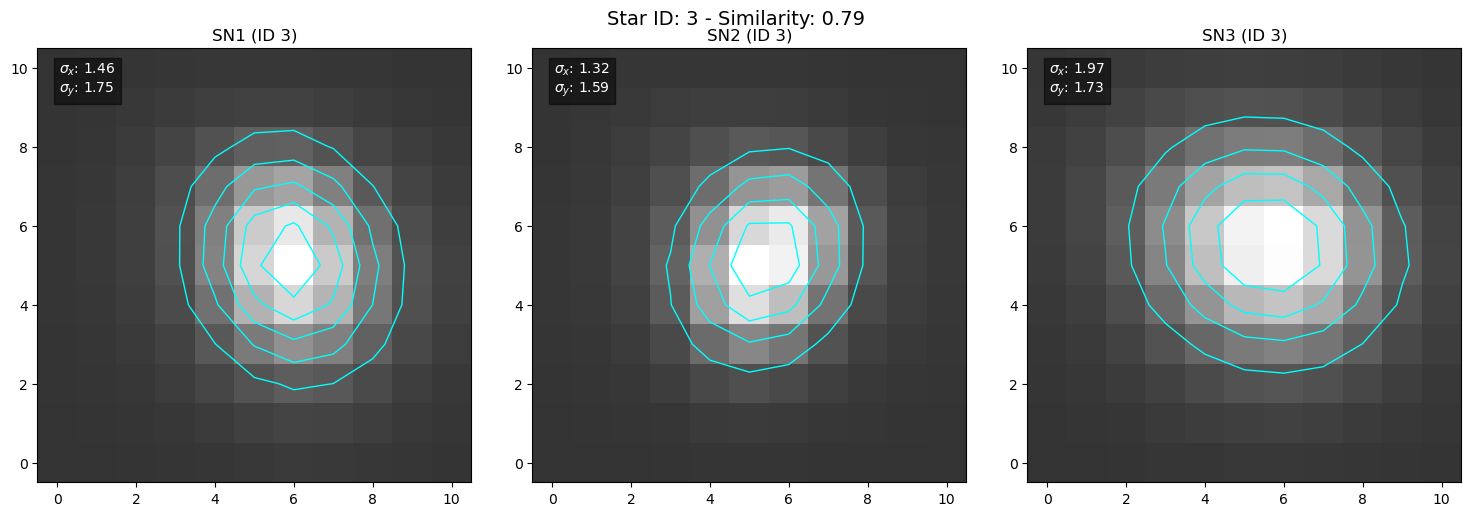

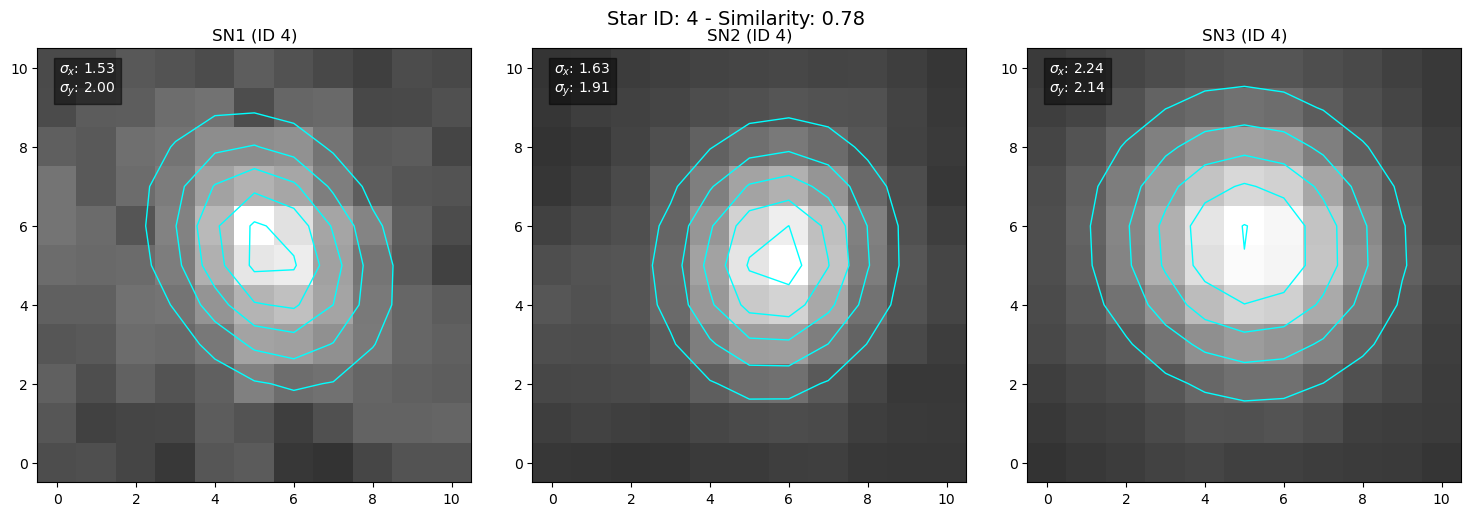

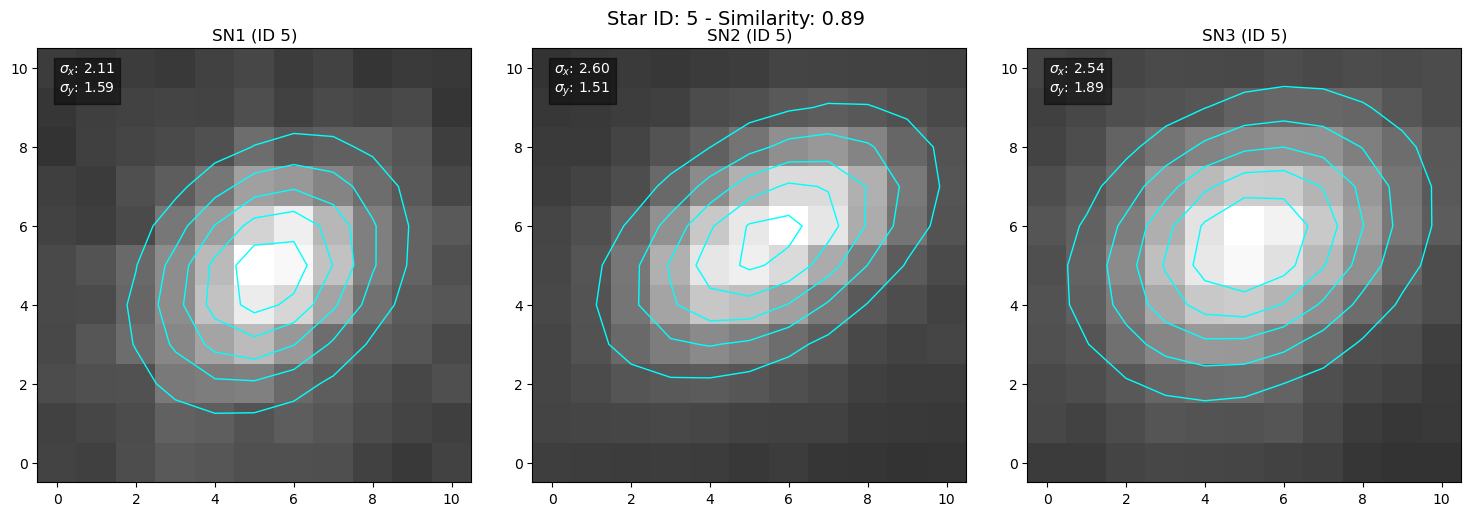

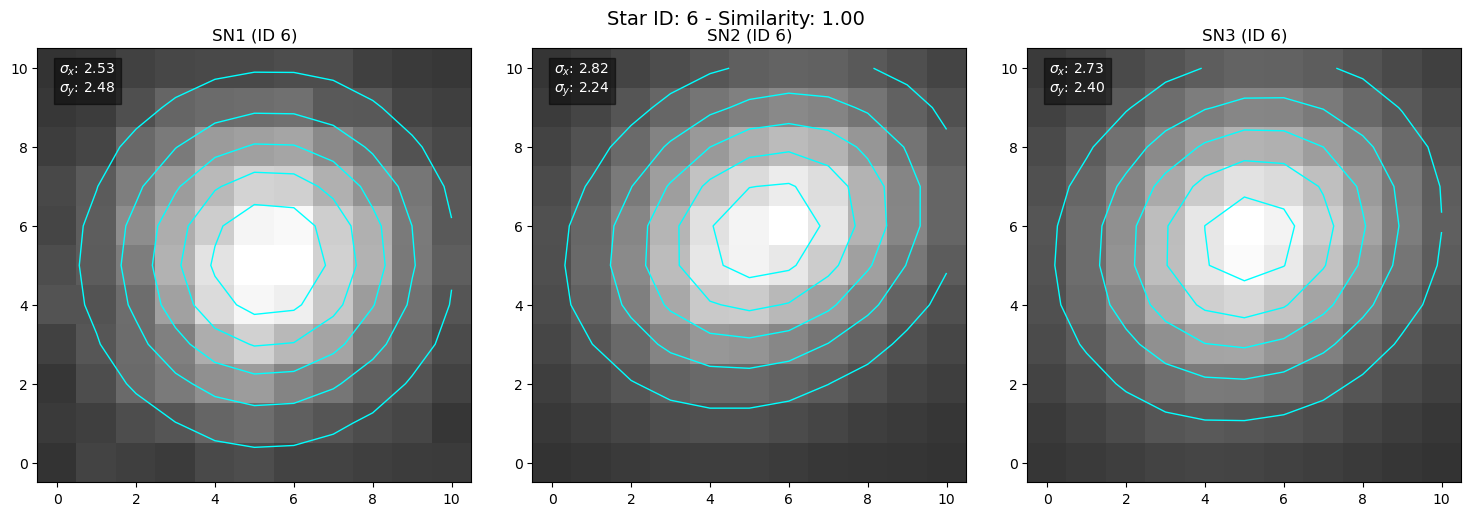

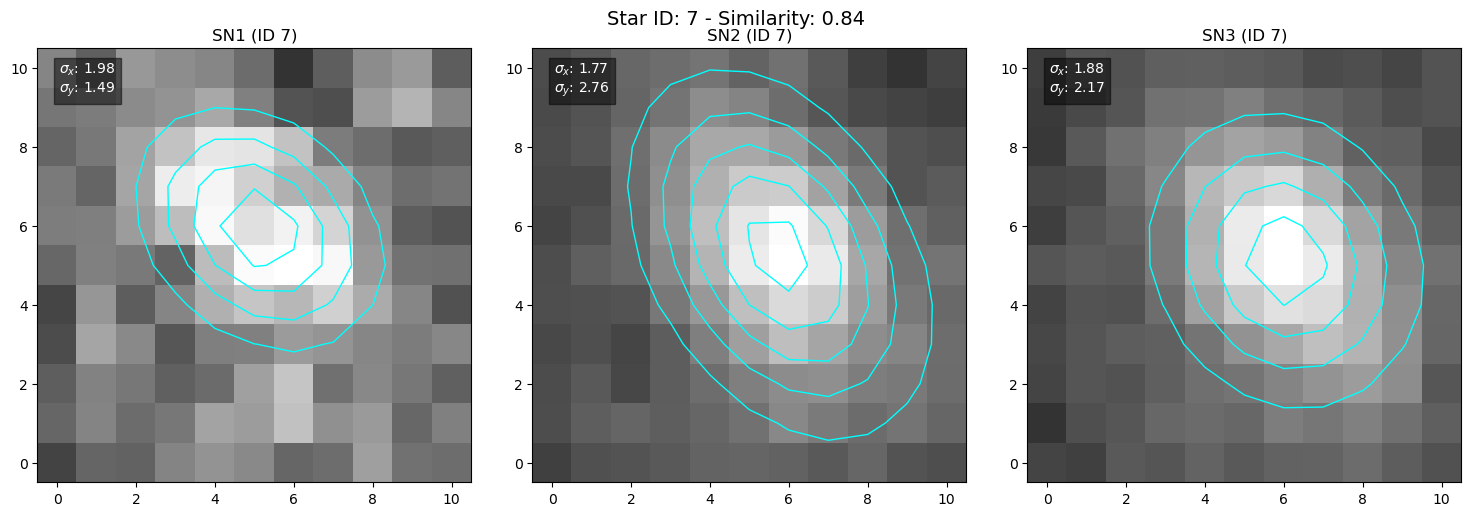

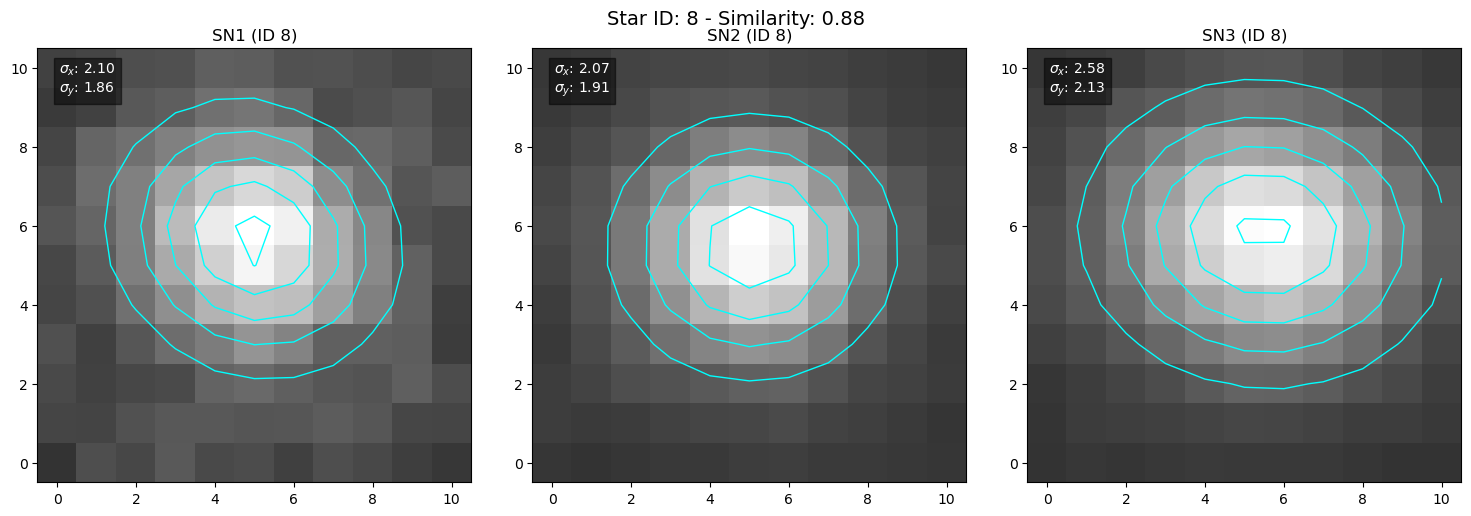

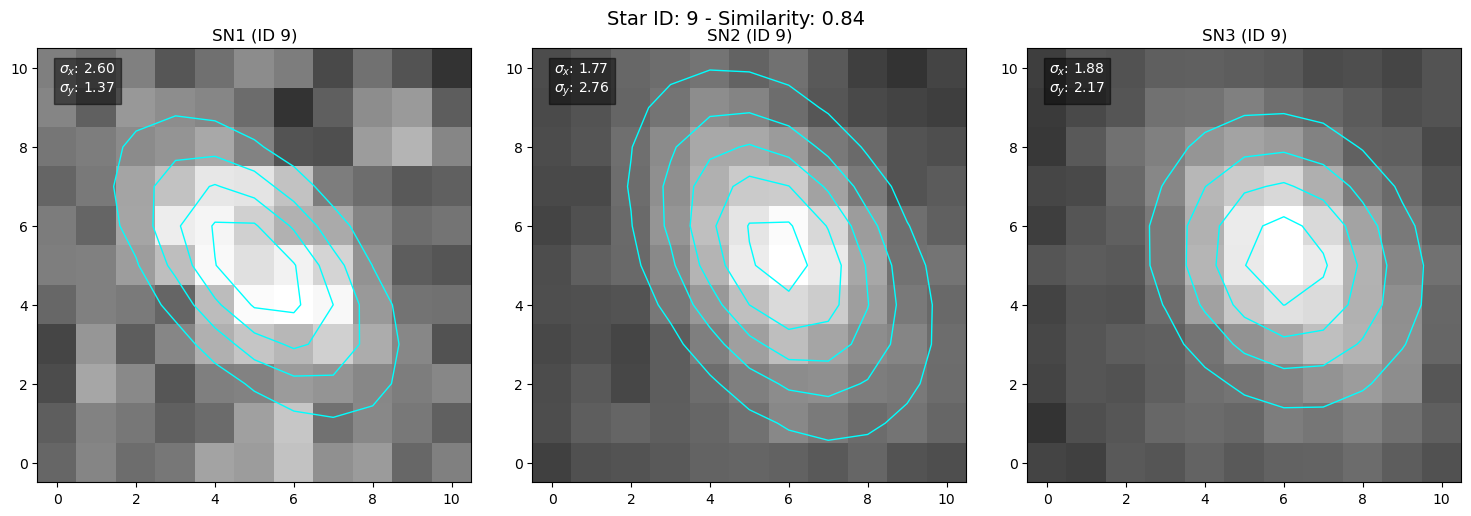

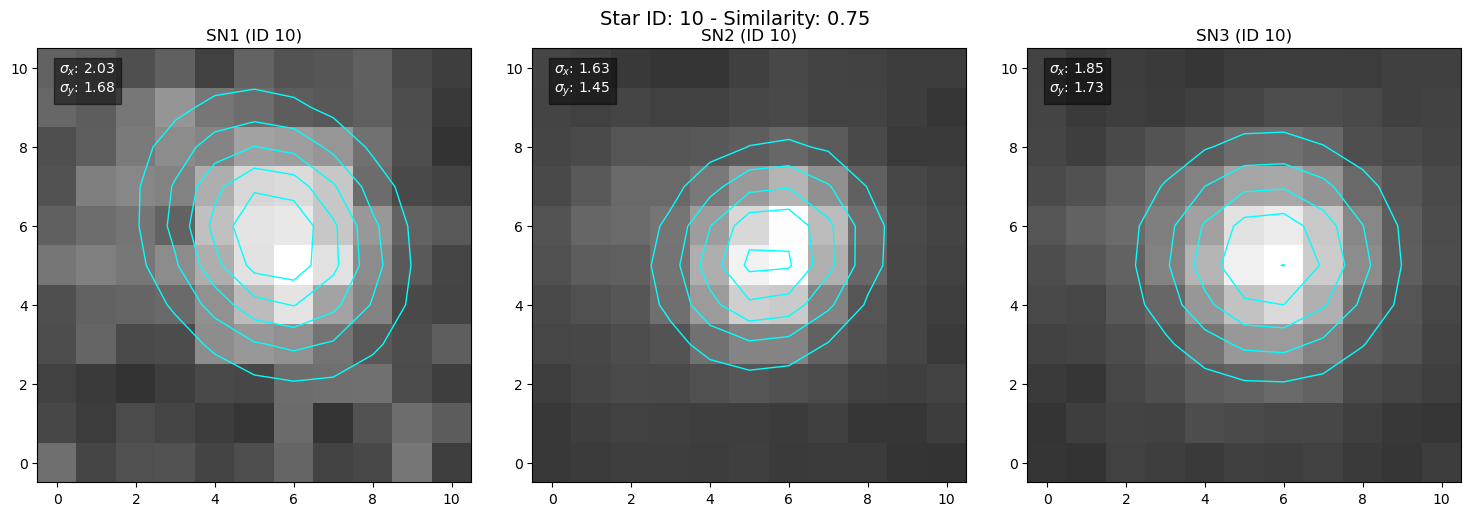

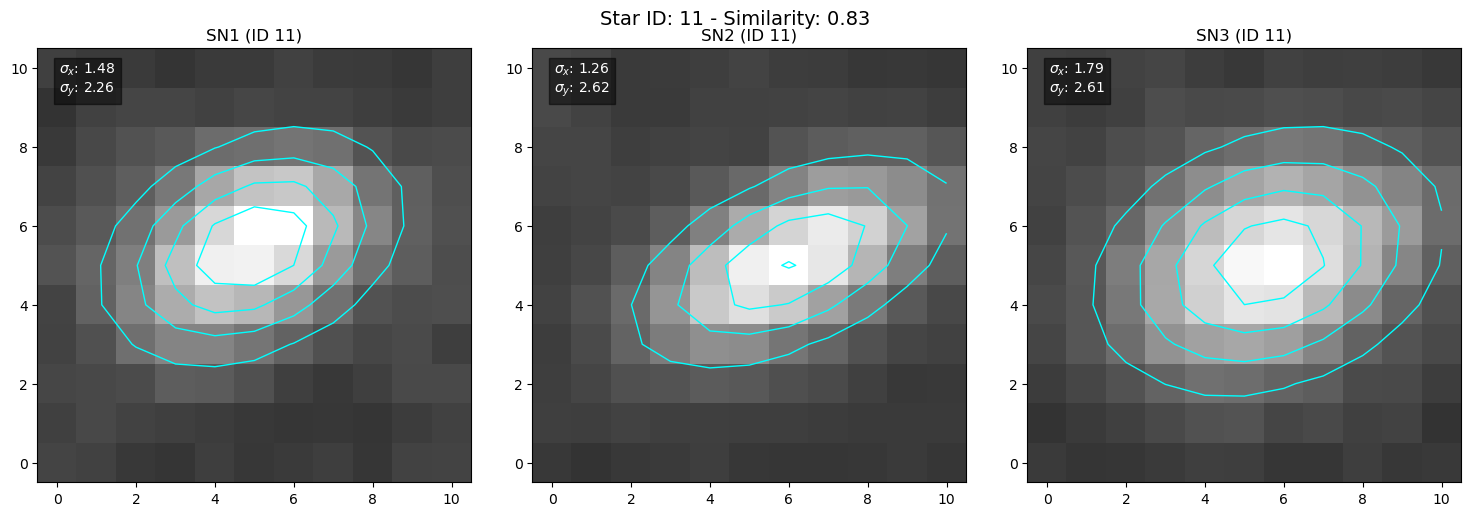

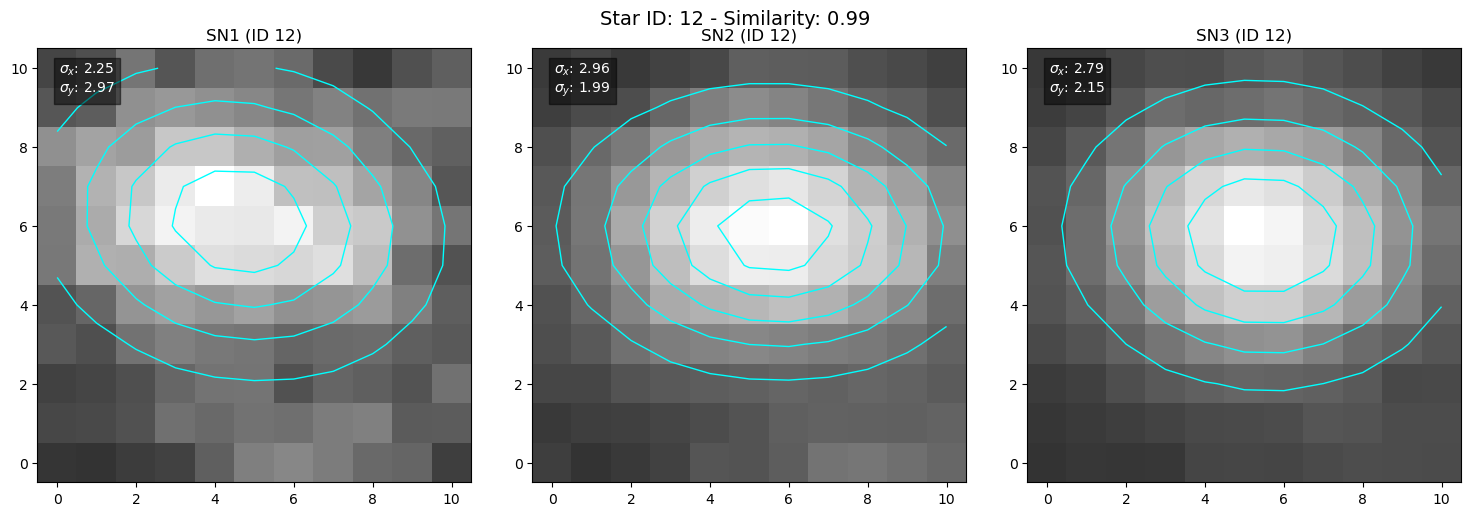

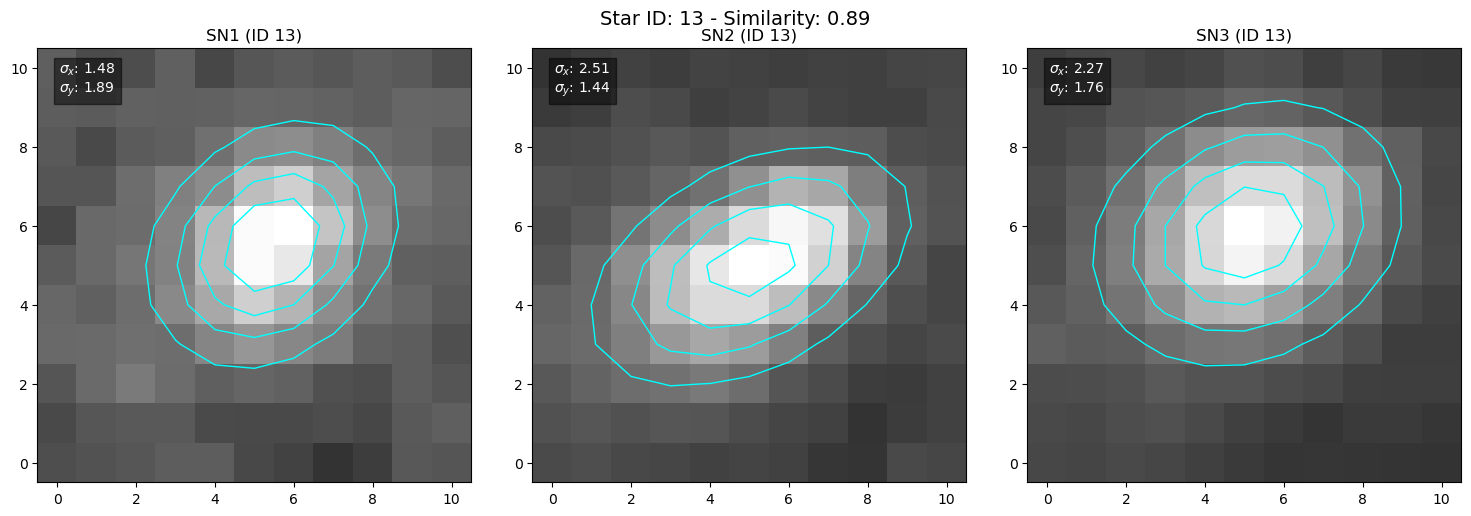

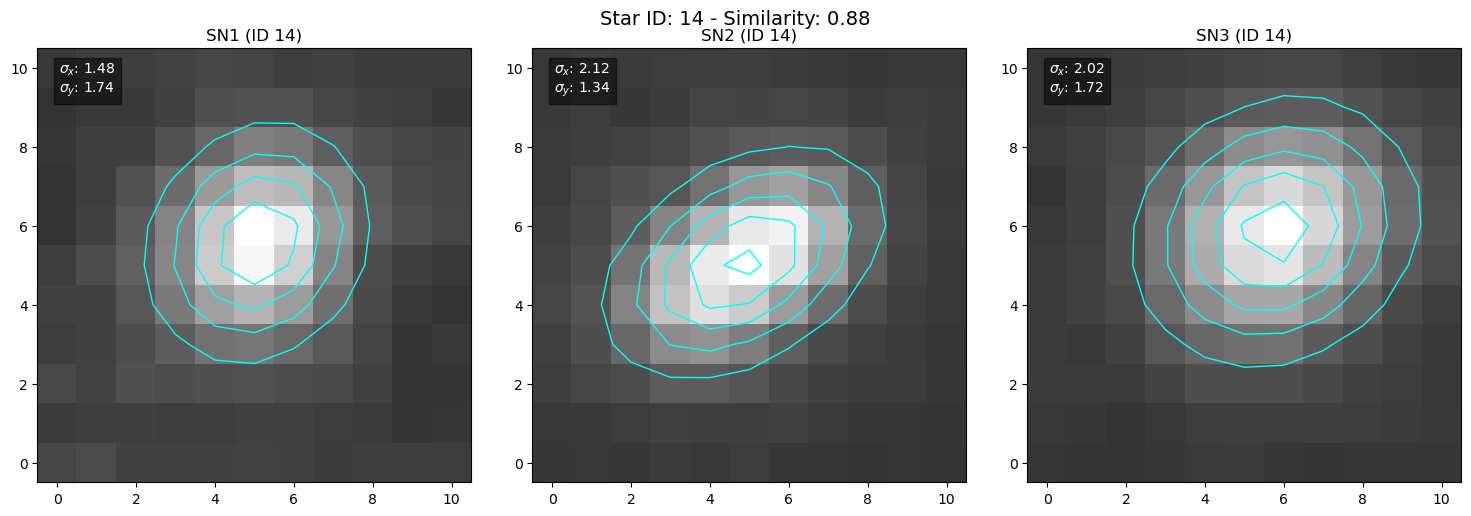

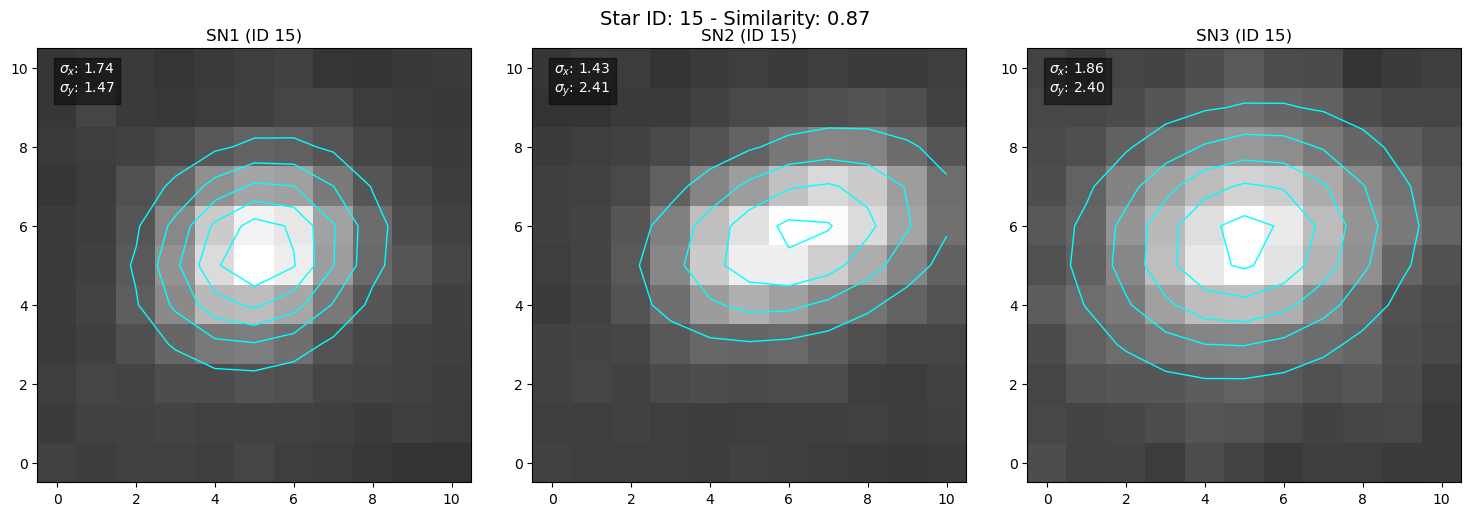

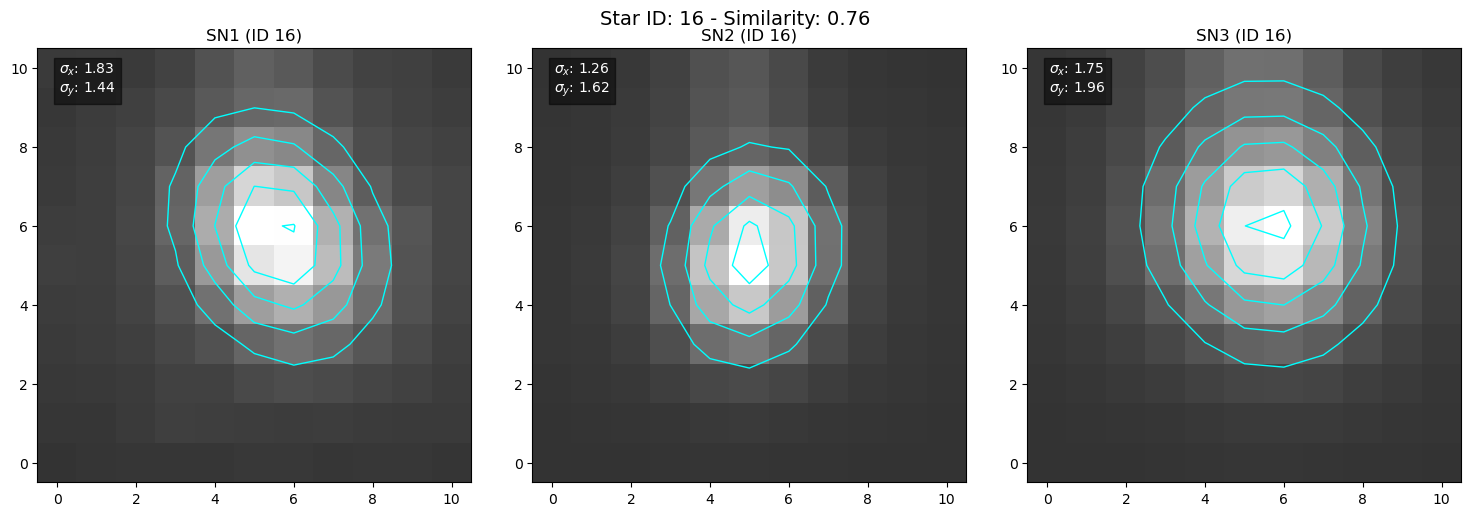

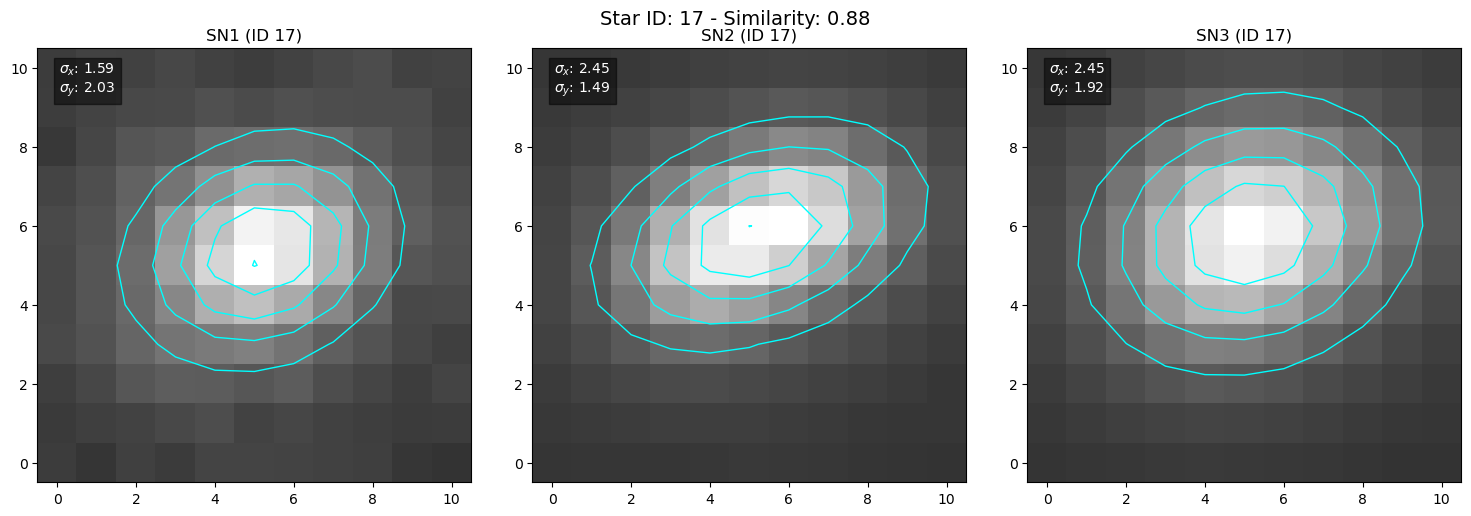

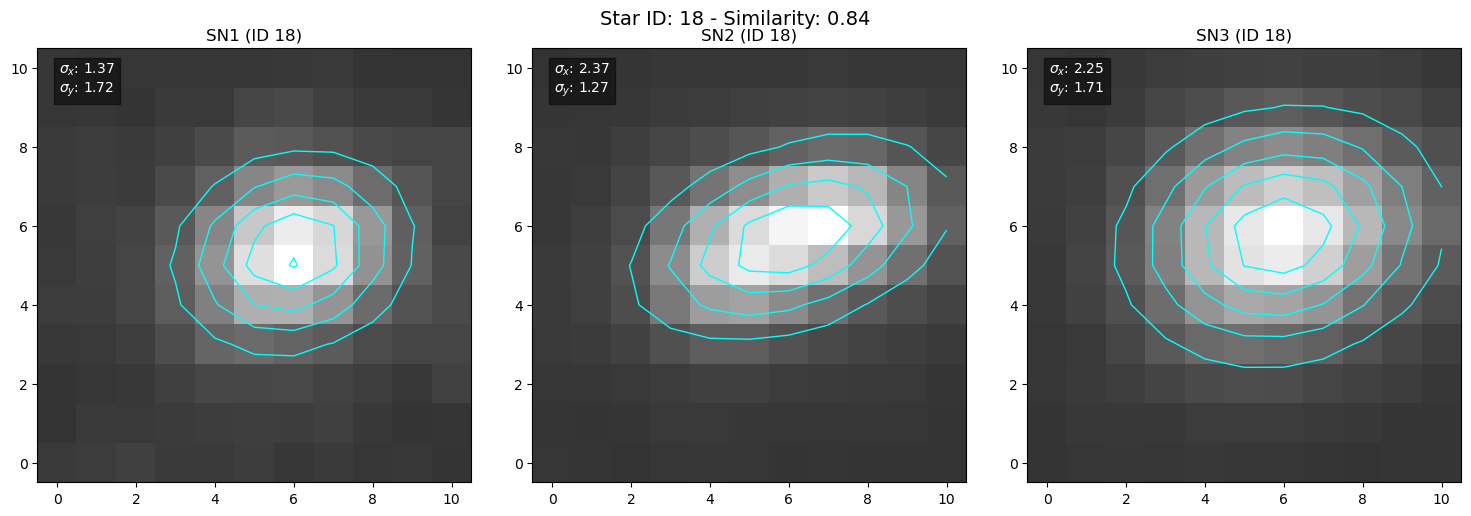

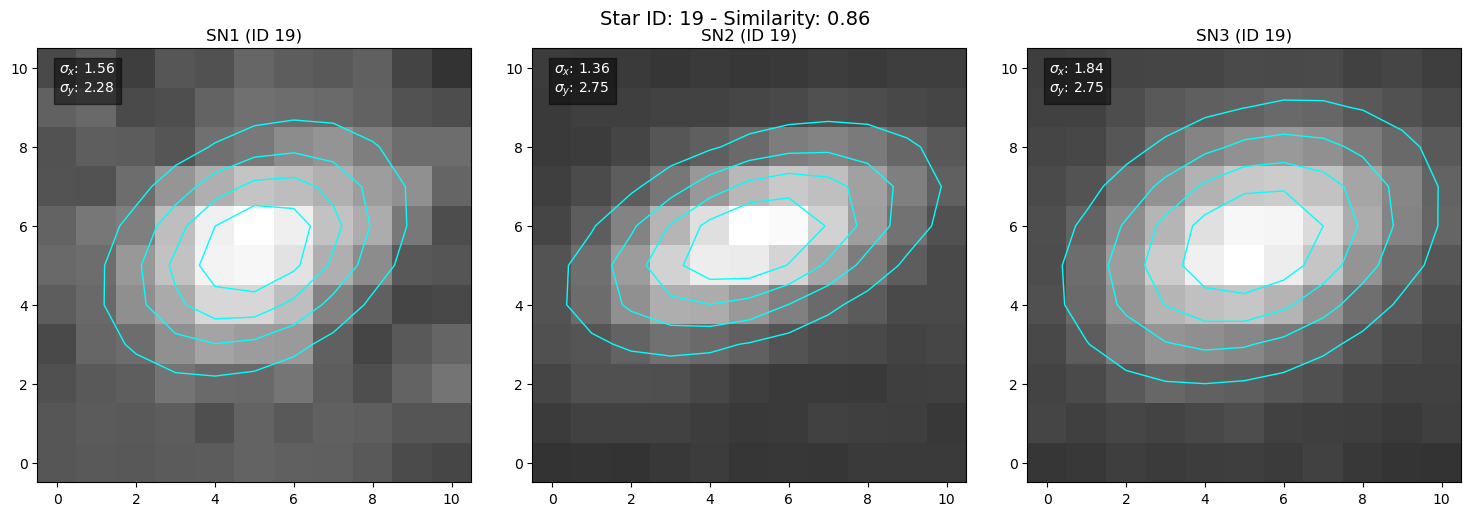

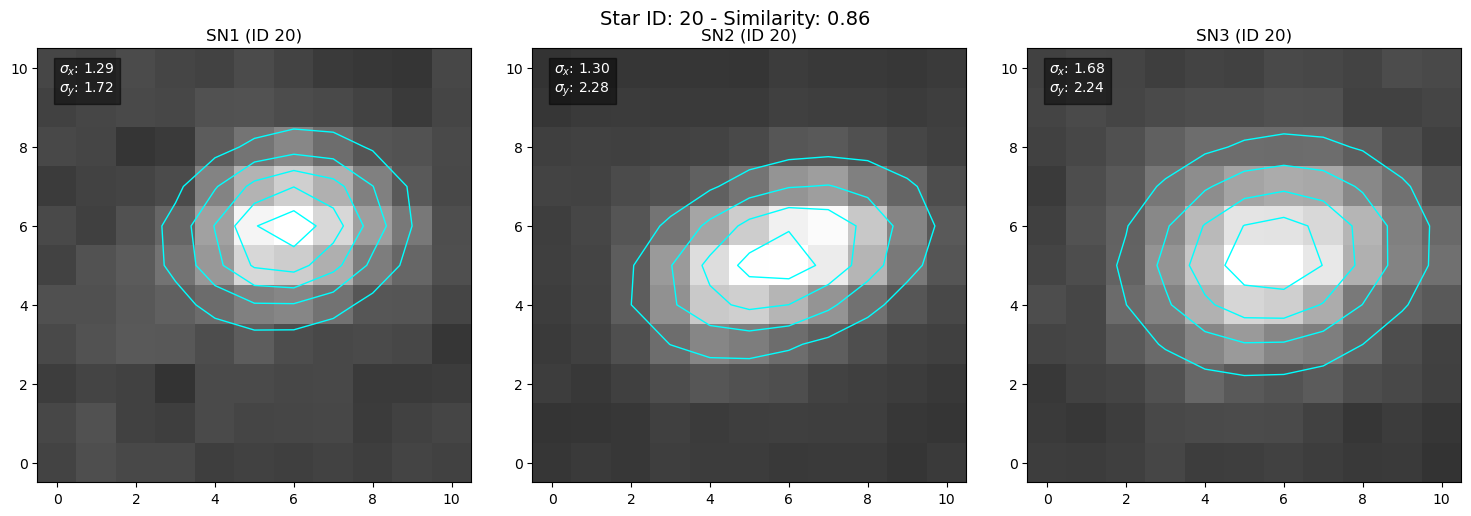

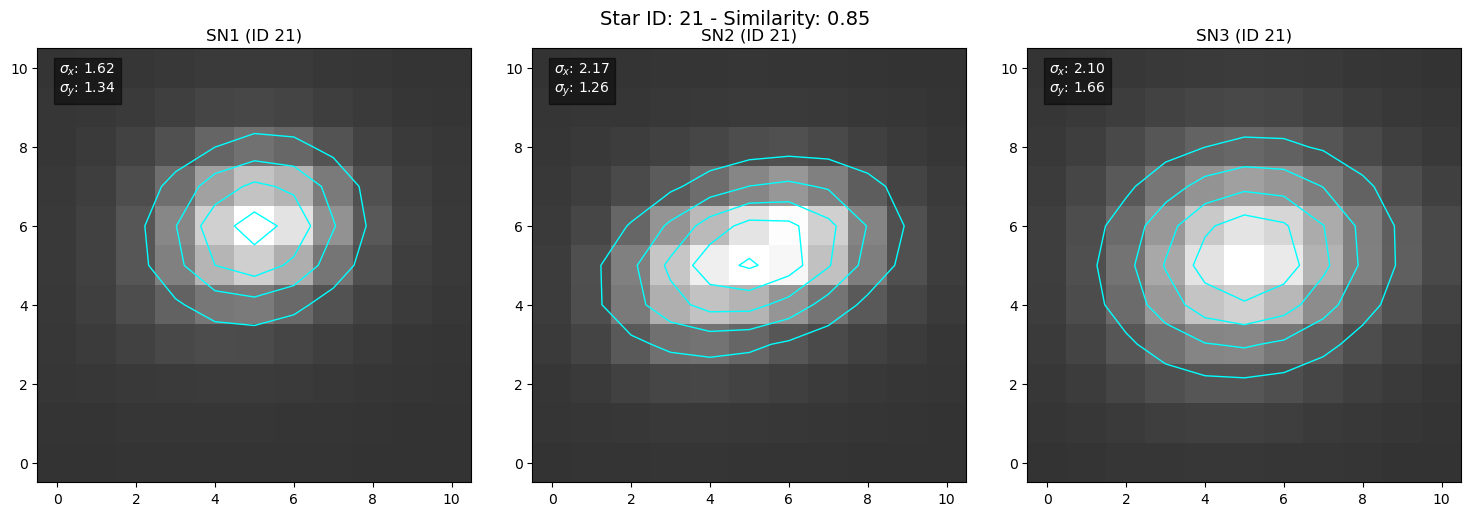

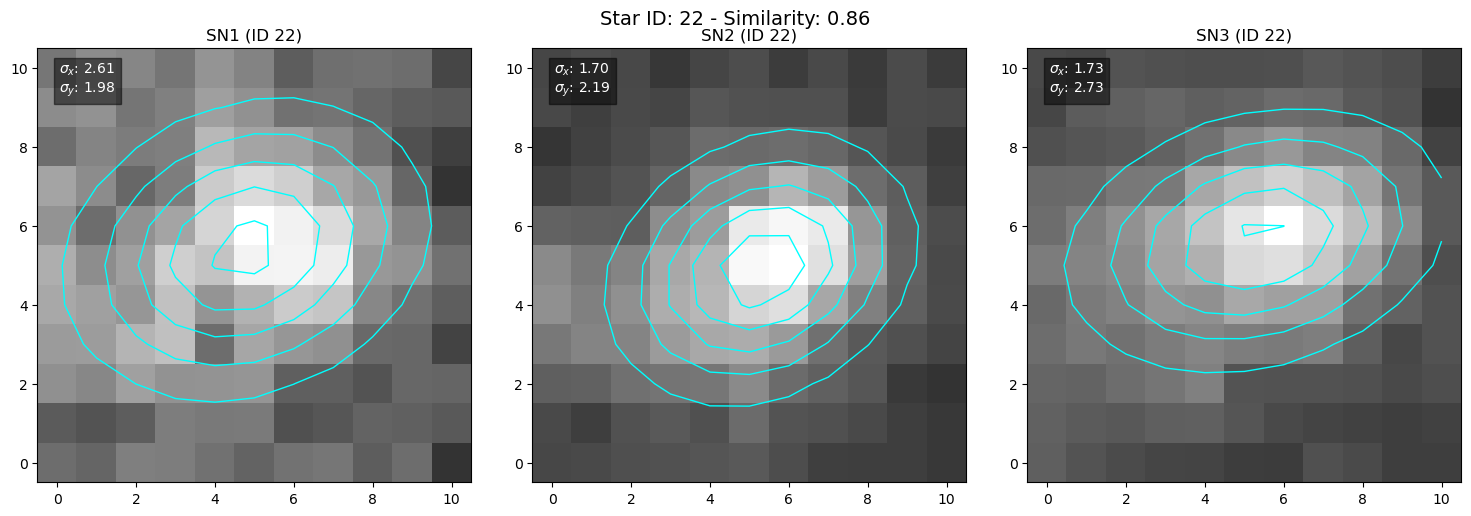

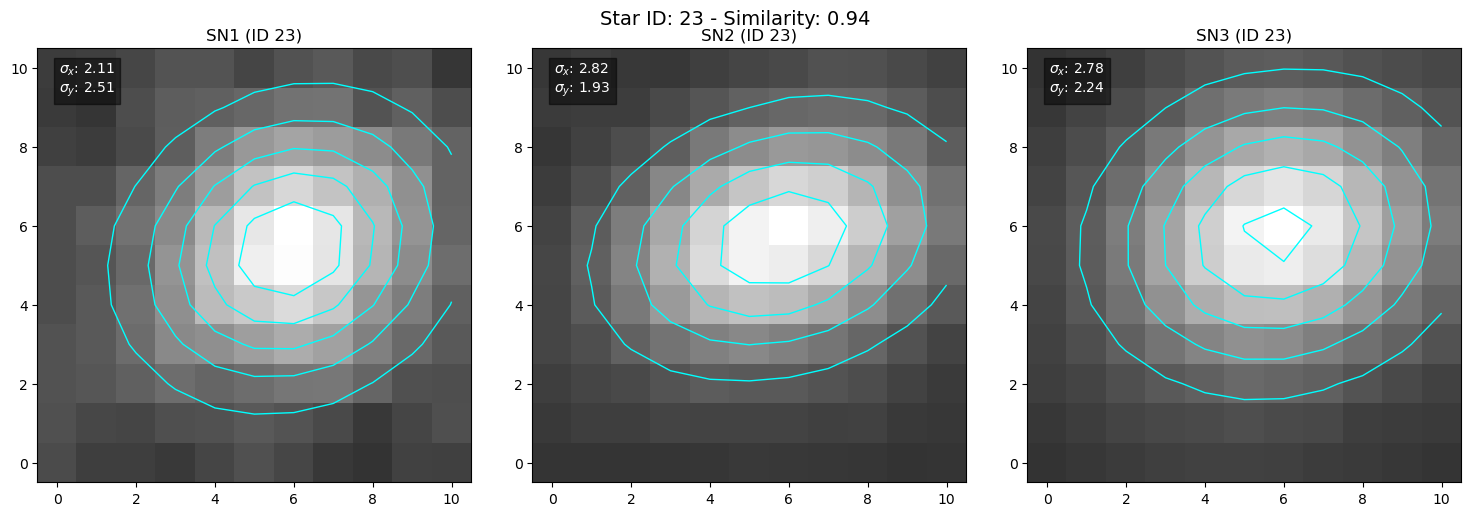

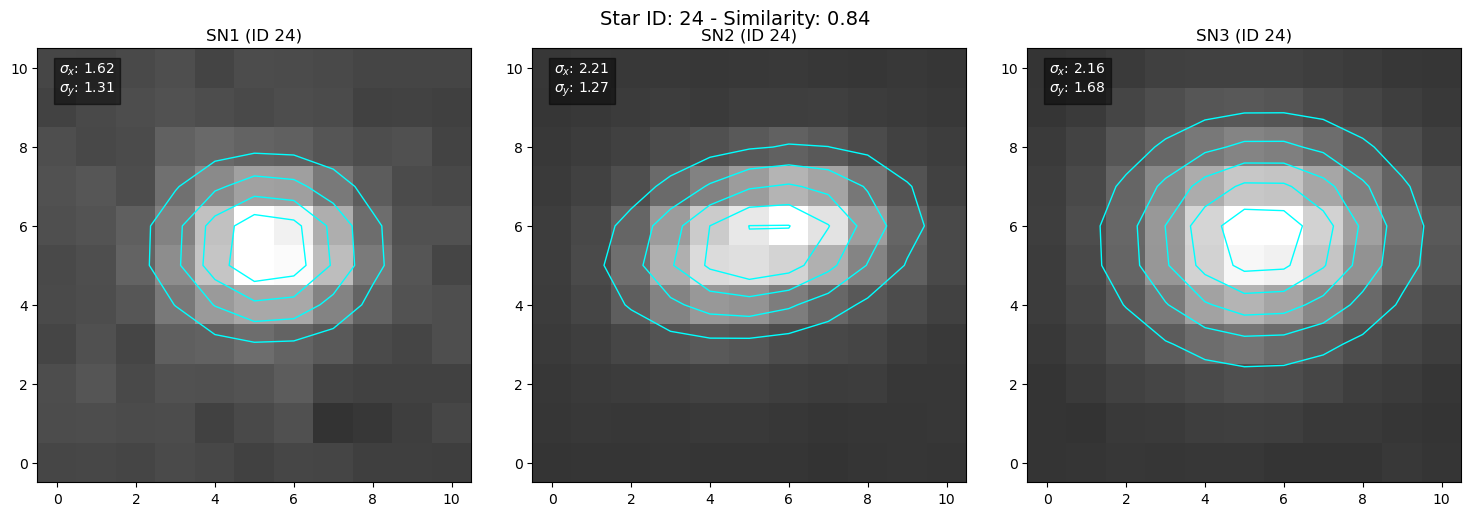

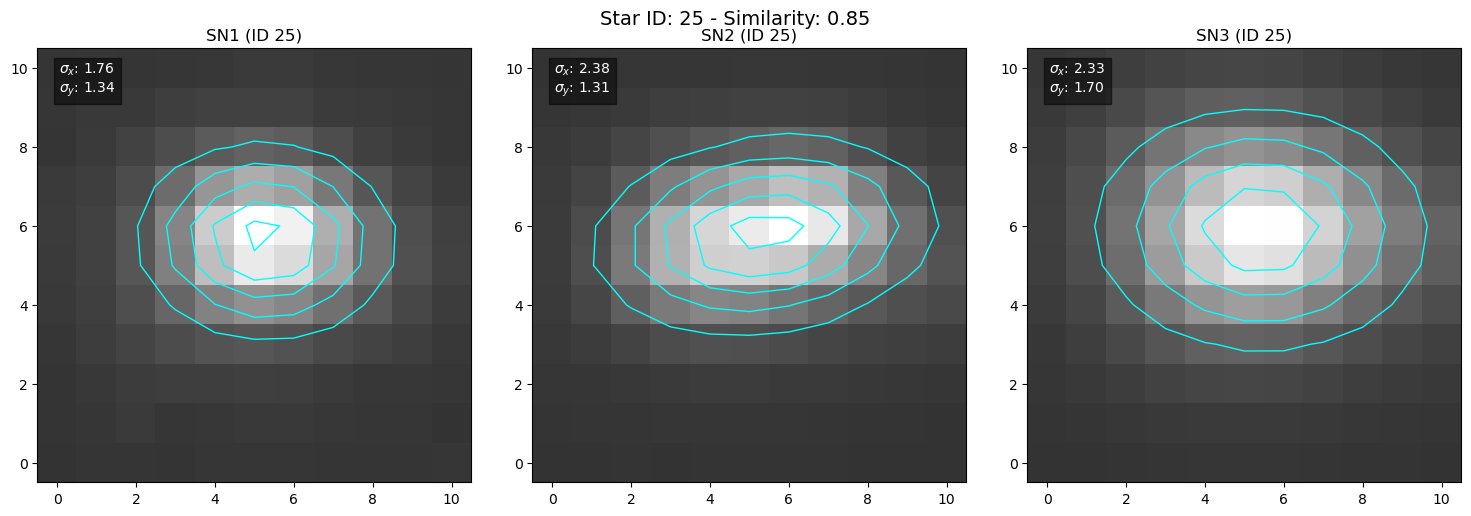

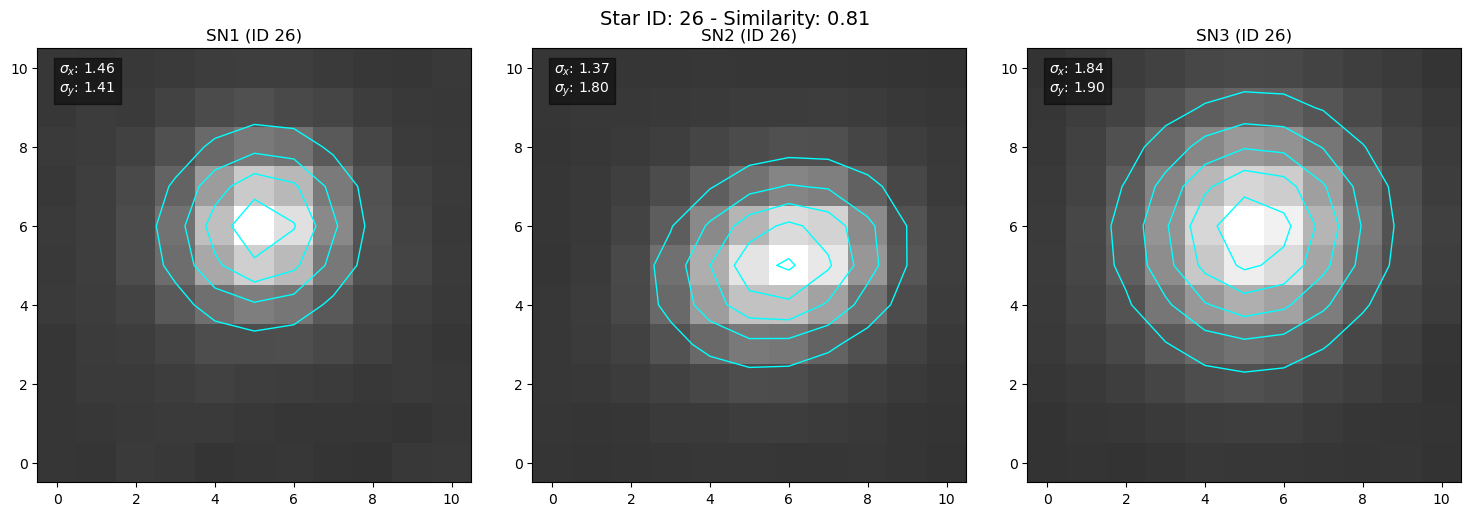

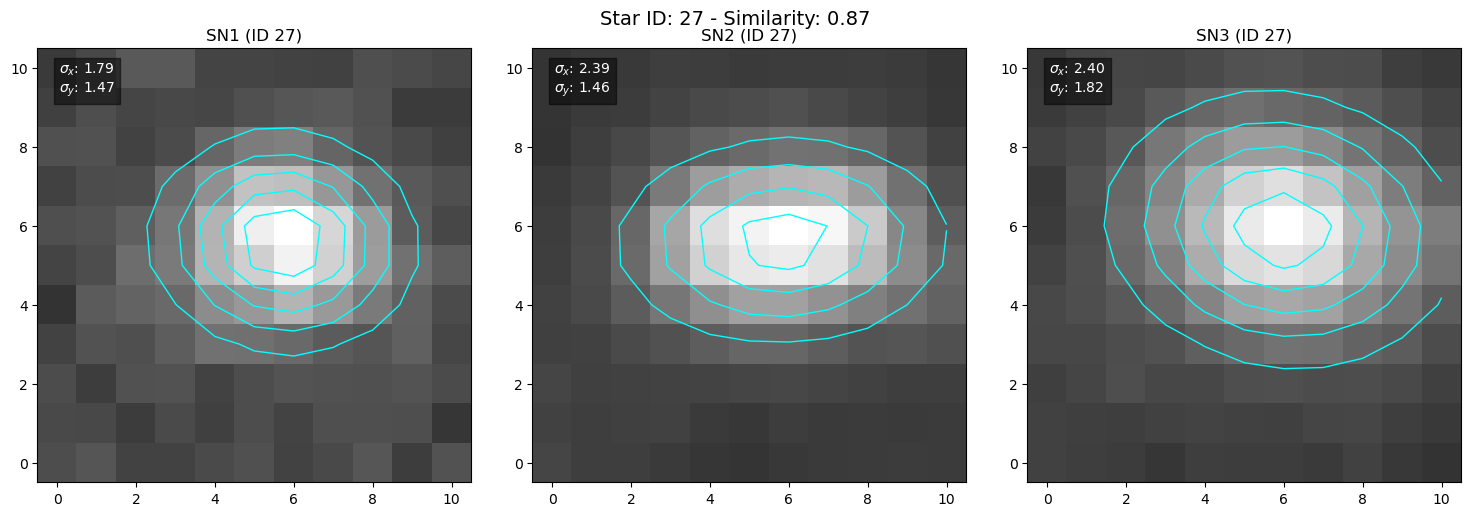

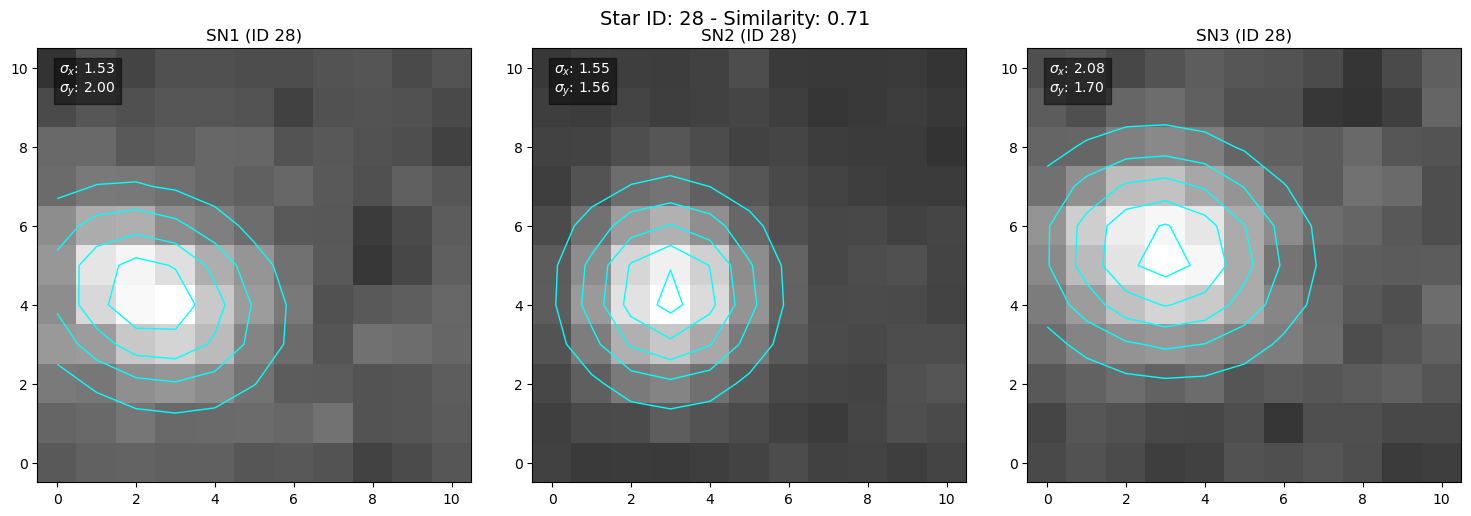

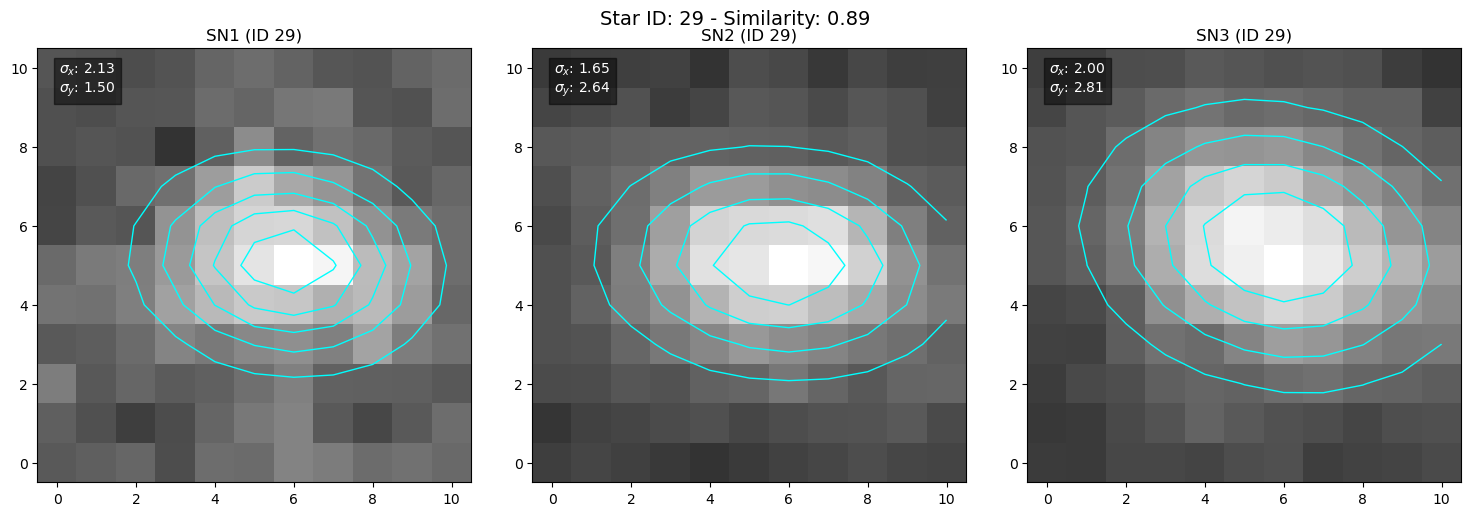

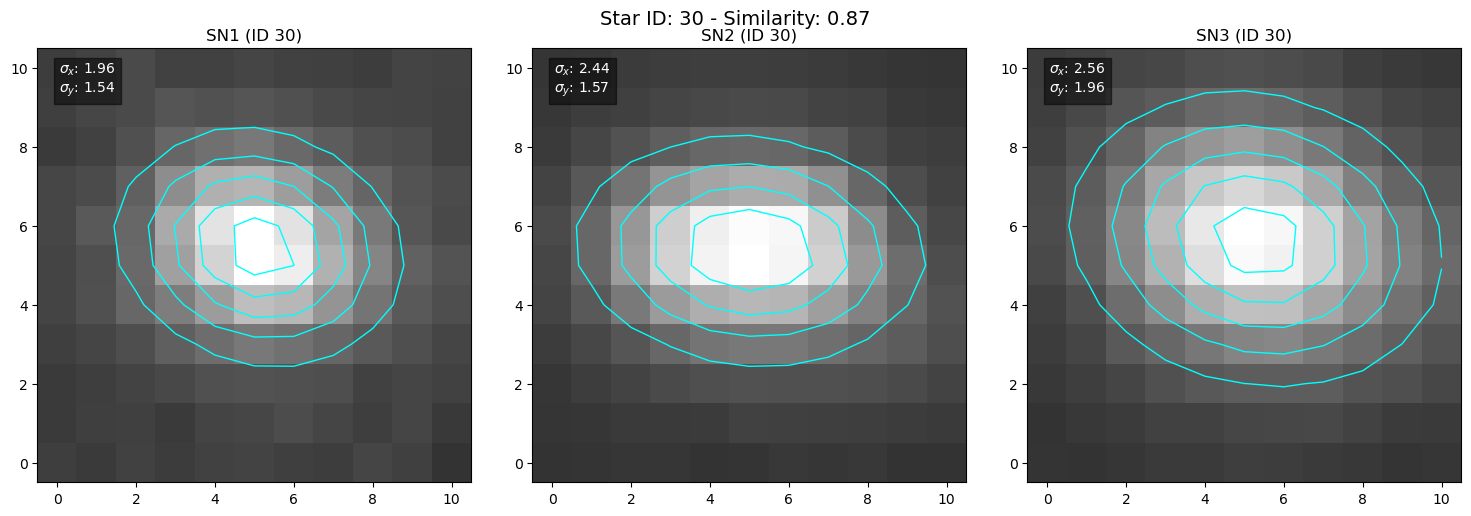

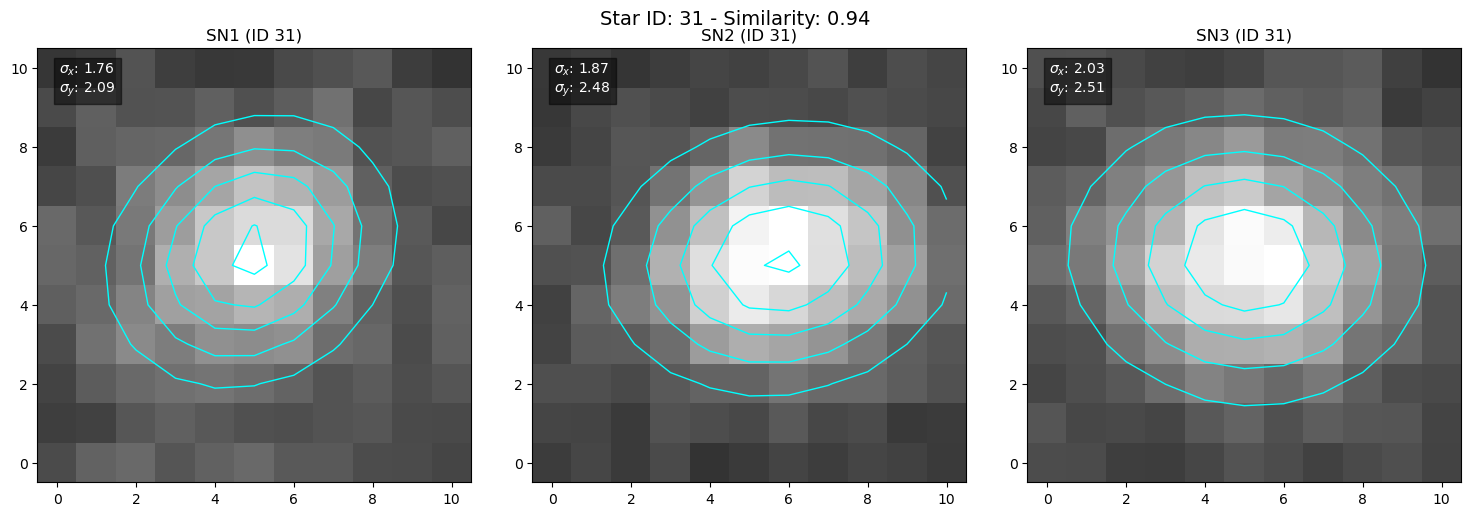

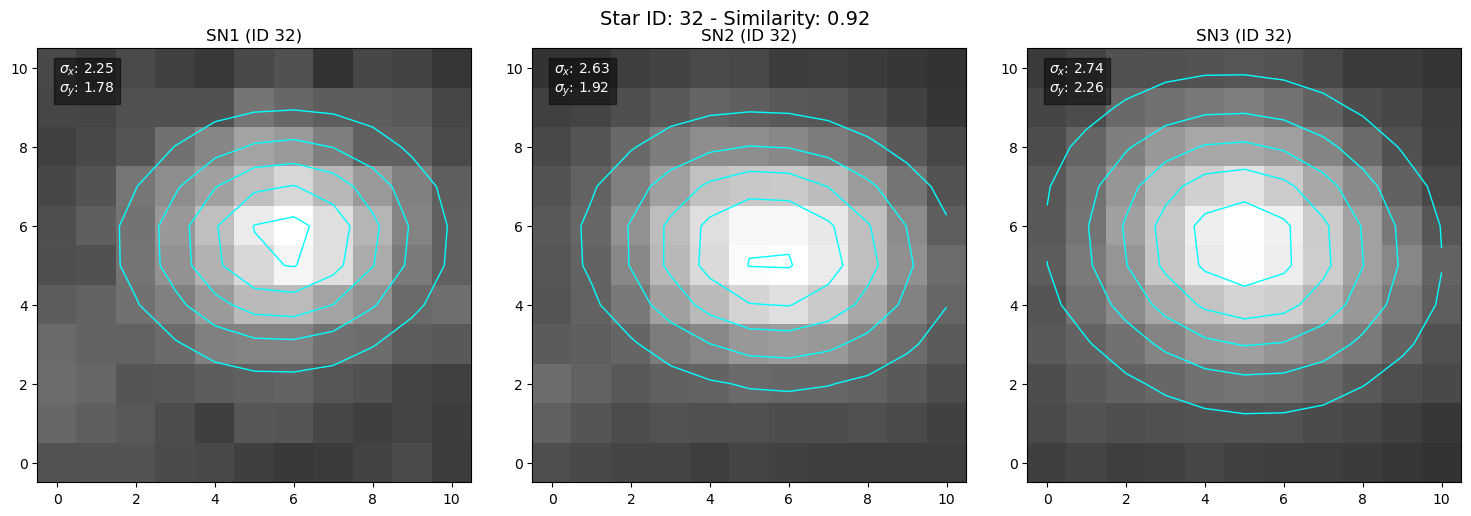

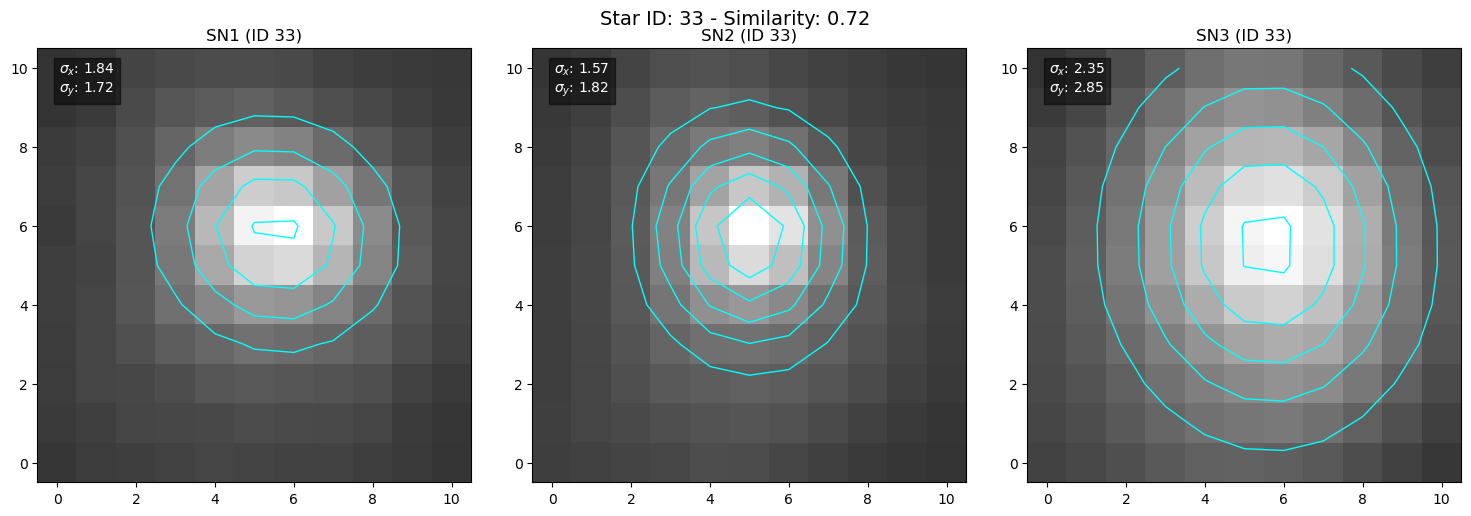

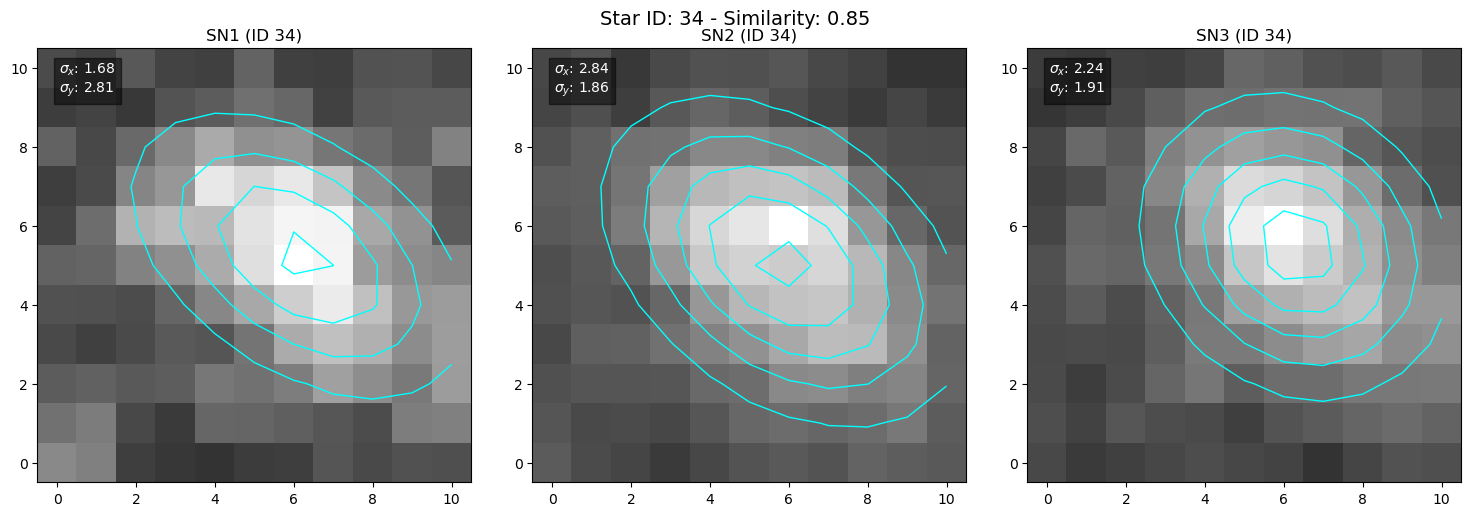

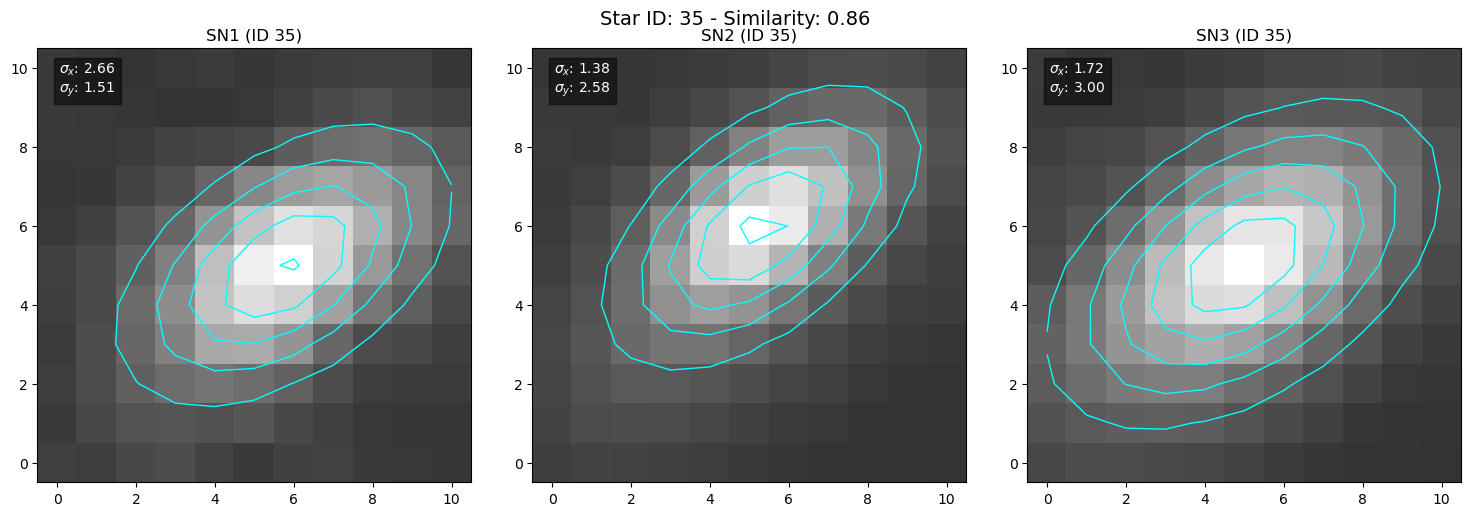

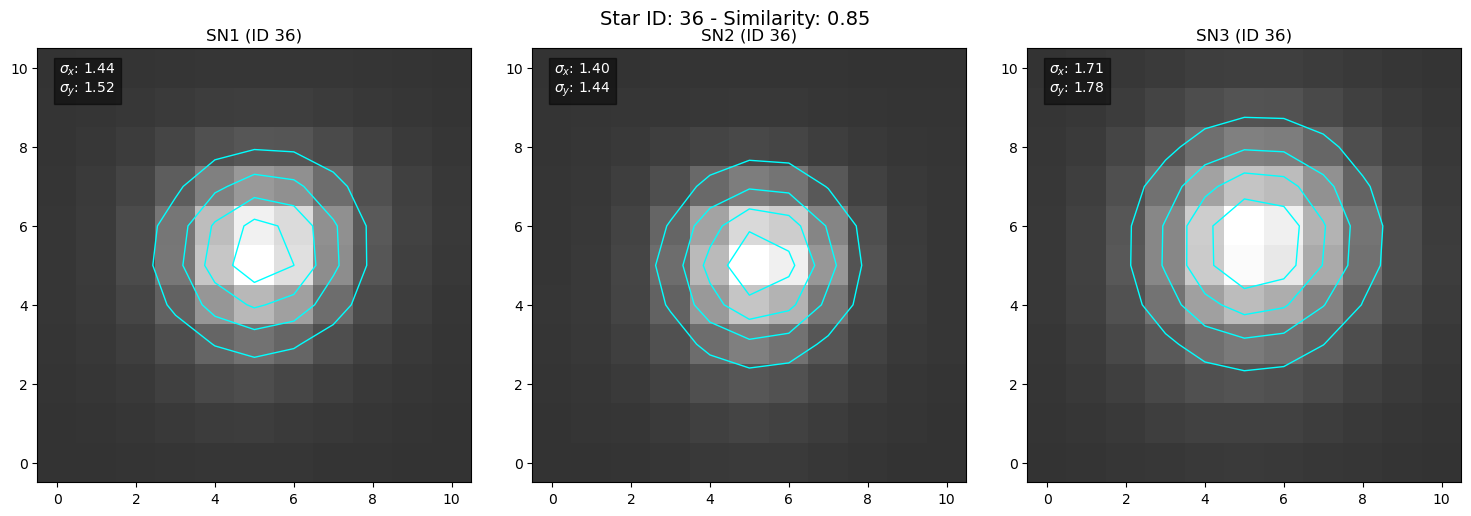

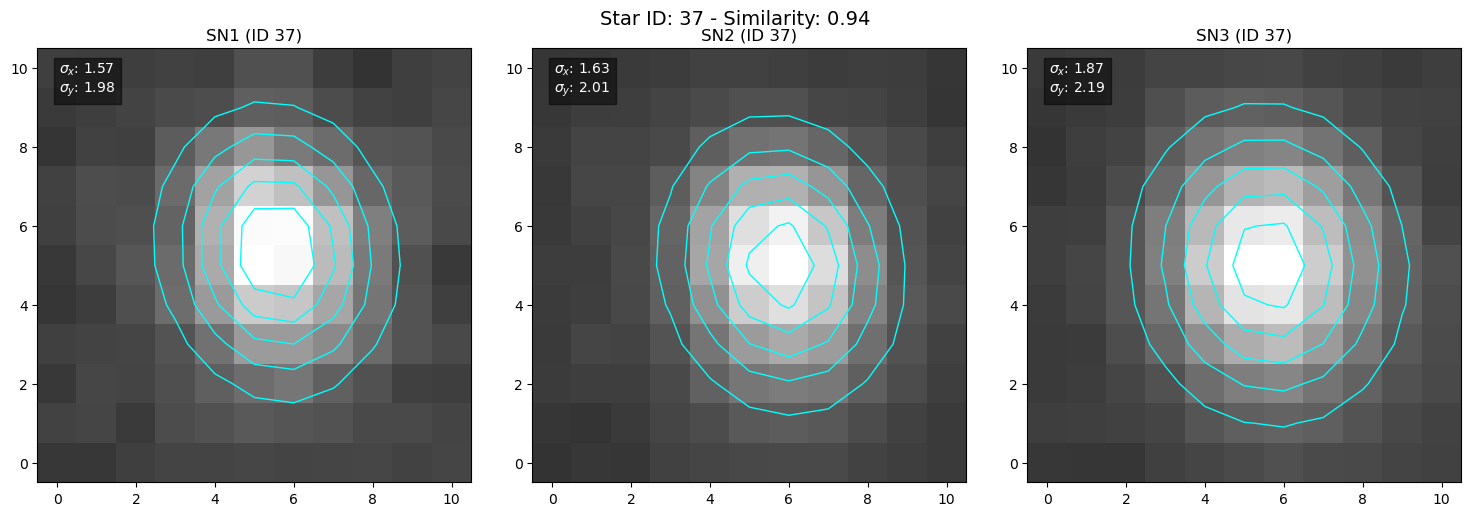

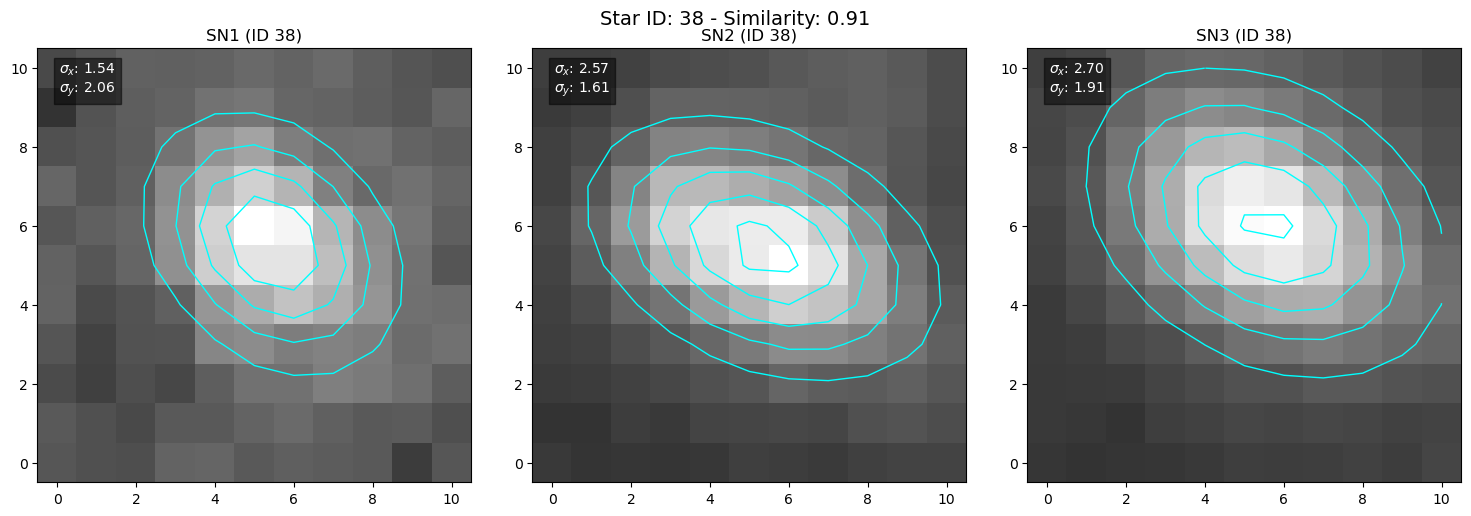

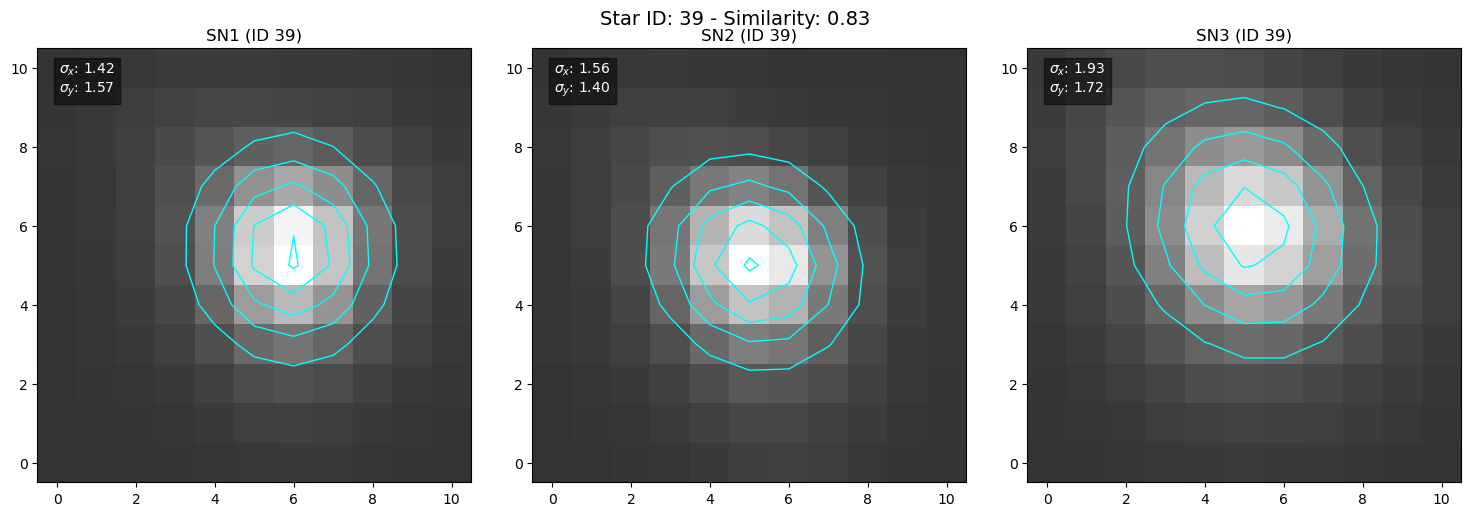

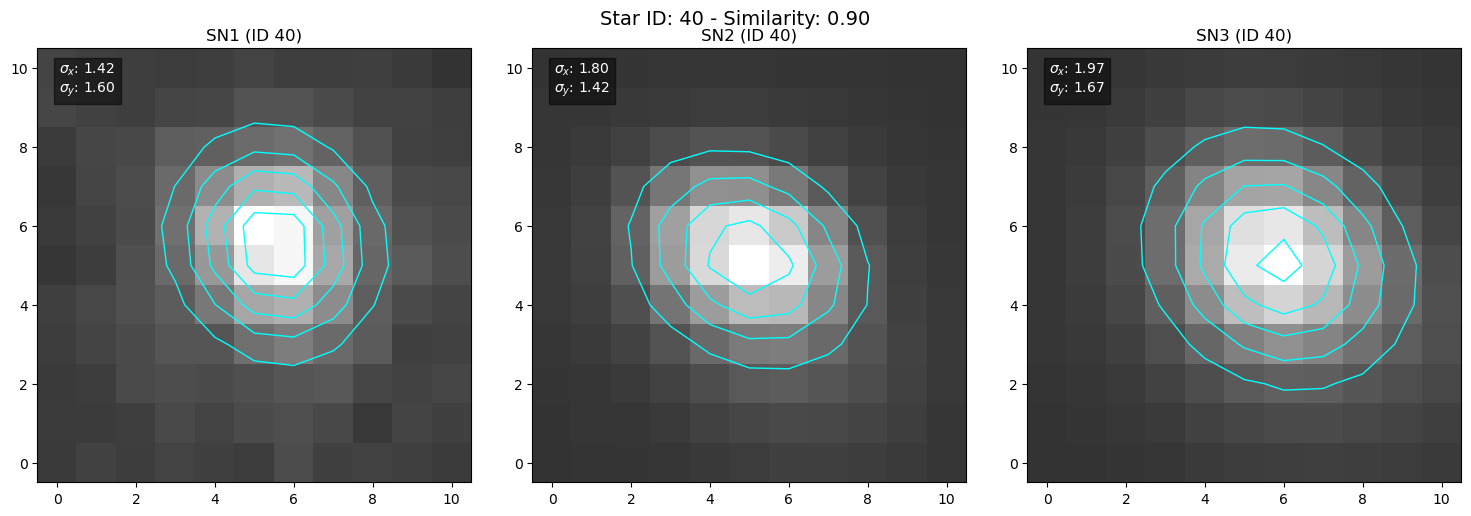

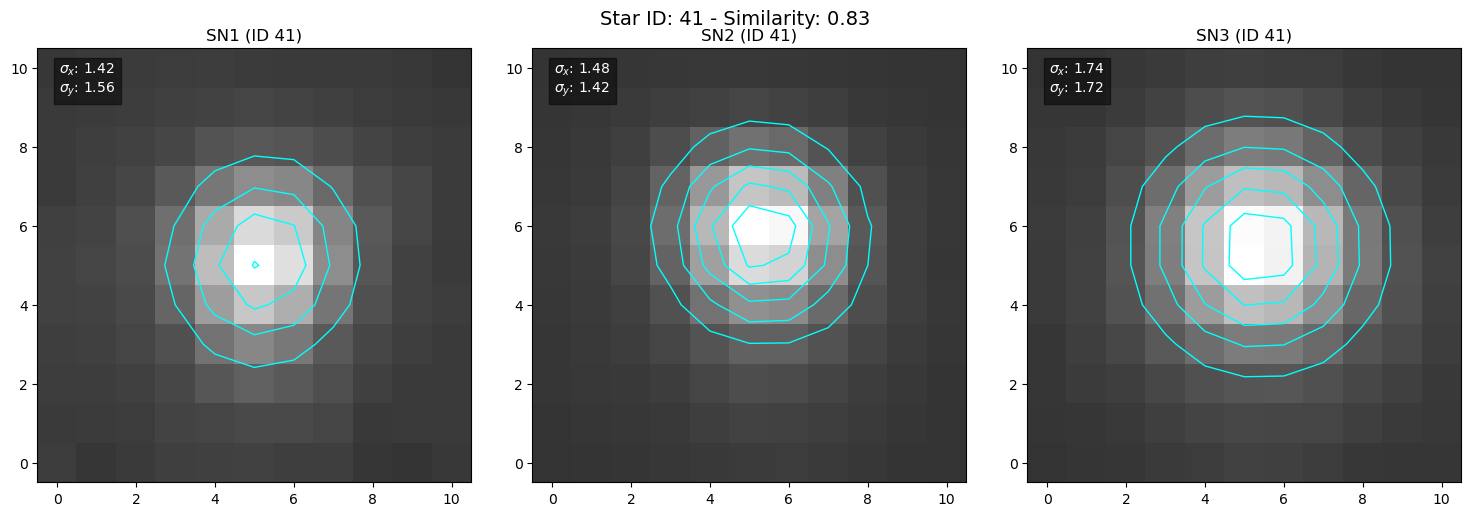

In [20]:

### Check individual stars used here

# Définir le seuil de similarité
similarity_threshold_min = 0.7
similarity_threshold_max = 1
similarity = all_stars_table4['similarity']

# Filtrer les étoiles dans l'intervalle de similarité
filtered_indices = np.where((similarity >= similarity_threshold_min) & (similarity <= similarity_threshold_max))[0]

# Afficher les étoiles dans chaque cube avec les contours et la similarité
for idx in filtered_indices:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Récupérer les paramètres de la PSF pour chaque cube
    star_SN1 = [all_stars_table4['xcentroid_SN1'][idx], all_stars_table4['ycentroid_SN1'][idx]]
    star_SN2 = [all_stars_table4['xcentroid_SN2'][idx], all_stars_table4['ycentroid_SN2'][idx]]
    star_SN3 = [all_stars_table4['xcentroid_SN3'][idx], all_stars_table4['ycentroid_SN3'][idx]]
    
    # Extraire les paramètres ajustés pour le modèle de l’étoile
    params_SN1 = [all_stars_table4['amplitude_SN1'][idx], all_stars_table4['x_center_SN1'][idx], all_stars_table4['y_center_SN1'][idx],
                  all_stars_table4['sigma_x_SN1'][idx], all_stars_table4['sigma_y_SN1'][idx], all_stars_table4['theta_SN1'][idx]]
    params_SN2 = [all_stars_table4['amplitude_SN2'][idx], all_stars_table4['x_center_SN2'][idx], all_stars_table4['y_center_SN2'][idx],
                  all_stars_table4['sigma_x_SN2'][idx], all_stars_table4['sigma_y_SN2'][idx], all_stars_table4['theta_SN2'][idx]]
    params_SN3 = [all_stars_table4['amplitude_SN3'][idx], all_stars_table4['x_center_SN3'][idx], all_stars_table4['y_center_SN3'][idx],
                  all_stars_table4['sigma_x_SN3'][idx], all_stars_table4['sigma_y_SN3'][idx], all_stars_table4['theta_SN3'][idx]]

    # Charger les images autour de chaque étoile
    for ax, star, params, image, title in zip(
            axes, [star_SN1, star_SN2, star_SN3], [params_SN1, params_SN2, params_SN3],
            [deep_frame_SN1, deep_frame_SN2, deep_frame_SN3], 
            ['SN1', 'SN2', 'SN3']):
        
        # Extraire une sous-image autour de l'étoile
        size = 5
        y_min = max(int(star[1] - size), 0)
        y_max = min(int(star[1] + size + 1), image.shape[0])
        x_min = max(int(star[0] - size), 0)
        x_max = min(int(star[0] + size + 1), image.shape[1])
        sub_image = image[y_min:y_max, x_min:x_max]
        
        # Vérifier que la sous-image est assez grande pour afficher les contours
        if sub_image.shape[0] < 2 or sub_image.shape[1] < 2:
            print(f"Sub-image for star {idx} in {title} is too small, skipping contour.")
            continue
        
        # Afficher l'image de l'étoile
        ax.imshow(sub_image, origin='lower', cmap='gray', alpha=0.8)
        
        # Créer le modèle de contour avec les paramètres ajustés
        gaussian = models.Gaussian2D(amplitude=params[0], x_mean=params[1]-x_min, y_mean=params[2]-y_min, 
                                     x_stddev=params[3], y_stddev=params[4], theta=params[5])
        y, x = np.mgrid[:sub_image.shape[0], :sub_image.shape[1]]
        model_data = gaussian(x, y)
        
        # Superposer les contours du modèle
        ax.contour(model_data, colors='cyan', levels=5, linewidths=1)
        ax.set_title(f'{title} (ID {idx})')

        # Ajouter les valeurs de sigma_x et sigma_y en annotation
        ax.text(0.05, 0.9, f'$\\sigma_x$: {params[3]:.2f}\n$\\sigma_y$: {params[4]:.2f}', 
                transform=ax.transAxes, color='white', fontsize=10,
                bbox=dict(facecolor='black', alpha=0.5))
        
    # Ajouter la similarité en annotation
    similarity_score = similarity[idx]
    fig.suptitle(f'Star ID: {idx} - Similarity: {similarity_score:.2f}', fontsize=14)
    plt.tight_layout()
    plt.show()


# Run again for the other SN

In [58]:
#...

# Results:

In [21]:

print('SN1:', nbstarsn1)
print(SN1_sol1,SN1_res1,SN1_dist1)
print(SN1_sol2,SN1_res2,SN1_dist2)
print('SN2:', nbstarsn2)
print(SN2_sol1,SN2_res1,SN2_dist1)
print(SN2_sol2,SN2_res2,SN2_dist2)

#cutto=300
#SN1: 29
#[[ 9.99828940e-01  9.67842823e-04 -3.26992995e-01]
# [-7.22625037e-04  9.99486274e-01  3.08150087e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2635702150862692 0.8902590632129452
#[[ 9.99667801e-01  9.08713607e-04 -1.37337954e-01]
# [-7.12748418e-04  9.99494082e-01  3.10686679e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.21269382641949922 0.5744600661330984
#SN2: 37
#[[ 1.00061350e+00  8.75359915e-04 -2.34340143e+00]
# [-7.81248011e-04  1.00045318e+00  1.65622823e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2266422537225971 0.7451381452130107
#[[ 1.00056746e+00  8.53166365e-04 -2.20684142e+00]
# [-8.16518214e-04  1.00046176e+00  1.69990876e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.12047661807309899 0.39997515939371414

#cutto = 400:
#SN1: 37
#[[ 9.99800652e-01  9.13666541e-04 -2.54425860e-01]
# [-7.45747723e-04  9.99488808e-01  3.07944802e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.23928597187284942 0.8668494558924782
#[[ 9.99653070e-01  8.90398920e-04 -1.08604103e-01]
# [-7.23178327e-04  9.99462053e-01  3.14333169e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.20404846543294075 0.5700497658313282
#SN2: 46
#[[ 1.00061167e+00  8.79710552e-04 -2.35383830e+00]
# [-7.54997876e-04  1.00047374e+00  1.60966054e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.22313994303458595 0.7326946627119465
#[[ 1.00055056e+00  8.65926680e-04 -2.22287509e+00]
# [-8.01476535e-04  1.00046081e+00  1.70300662e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.14380720861948024 0.5581703259814171

#cutto x300-1800 y-300-1900 Ha < -18
#SN1: 24
#[[ 9.99867636e-01  1.03366648e-03 -3.94310365e-01]
# [-6.97588427e-04  9.99584657e-01  3.00312659e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2192801695734213 0.6309719066202699
#[[ 9.99701043e-01  9.72853358e-04 -2.00698484e-01]
# [-6.87342769e-04  9.99552454e-01  3.05311380e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.18970762229992486 0.5861105595581544
#SN2: 32
#[[ 1.00058822e+00  8.48051443e-04 -2.29828939e+00]
# [-8.00000274e-04  1.00041652e+00  1.70053727e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2108210385971034 0.5688126048876598
#[[ 1.00055069e+00  8.45519986e-04 -2.18704397e+00]
# [-8.24859742e-04  1.00045725e+00  1.70771625e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.10663623575677914 0.4030634437526954

#cutto x300-1800 y-300-1900 Ha < -17.9
#SN1: 50
#[[ 9.99827941e-01  1.05541196e-03 -4.84947979e-01]
# [-7.35203609e-04  9.99530991e-01  3.00322050e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.33574452293127244 3.363561673740579
#[[ 9.99612660e-01  8.86141393e-04 -4.17322291e-02]
# [-7.04715991e-04  9.99479230e-01  3.09953329e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2257907050829389 0.8186327686345508
#SN2: 58
#[[ 1.00061106e+00  8.59939485e-04 -2.29752249e+00]
# [-8.20016788e-04  1.00047931e+00  1.62047819e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.23555936426915944 1.0697422661130833
#[[ 1.00051275e+00  8.43304346e-04 -2.15109052e+00]
# [-8.24252870e-04  1.00046102e+00  1.71135840e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.14009586396384627 0.5827305679710154

#cutto x300-1800 y-300-1900 Ha < -17.95
#SN1: 33
#[[ 9.99806399e-01  9.81914909e-04 -3.08525845e-01]
# [-6.98737791e-04  9.99598567e-01  2.92896953e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2320087574554083 0.45952293769231733
#[[ 9.99645290e-01  9.58923632e-04 -1.52124901e-01]
# [-6.73852852e-04  9.99533787e-01  3.03367567e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2059960335752818 0.5620528175420813
#SN2: 42
#[[ 1.00060114e+00  8.71278275e-04 -2.33809418e+00]
# [-8.23672699e-04  1.00036997e+00  1.73745801e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.225667877781766 0.9159490907156538
#[[ 1.00053960e+00  8.63859778e-04 -2.20657967e+00]
# [-8.21618720e-04  1.00042526e+00  1.74583204e+00]
# [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.12851753762167342 0.5569357531875572

SN1: 33
[[ 9.99806399e-01  9.81914909e-04 -3.08525845e-01]
 [-6.98737791e-04  9.99598567e-01  2.92896953e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2320087574554083 0.45952293769231733
[[ 9.99645290e-01  9.58923632e-04 -1.52124901e-01]
 [-6.73852852e-04  9.99533787e-01  3.03367567e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.2059960335752818 0.5620528175420813
SN2: 42
[[ 1.00060114e+00  8.71278275e-04 -2.33809418e+00]
 [-8.23672699e-04  1.00036997e+00  1.73745801e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.225667877781766 0.9159490907156538
[[ 1.00053960e+00  8.63859778e-04 -2.20657967e+00]
 [-8.21618720e-04  1.00042526e+00  1.74583204e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]] 0.12851753762167342 0.5569357531875572


In [22]:
## Save in json

# save cutto x300-1800 y-300-1900 Ha<-18

editjson='no' # Done 31 oct 25

if editjson == 'yes': 
    edit_json(jsonfile,'parametres_align_SN1',SN1_sol2.tolist())
    edit_json(jsonfile,'parametres_align_SN2',SN2_sol2.tolist())
    

#parametres_align_SN1  =  [[0.9997010430642563, 0.0009728533582390248, -0.2006984842332713], 
#                          [-0.00068734276943612, 0.9995524541587292, 3.0531137950290486], 
#                          [0.0, 0.0, 1.0]]  writen into json
#parametres_align_SN2  =  [[1.0005506900644727, 0.0008455199862572629, -2.1870439704669025], 
#                          [-0.0008248597418155546, 1.0004572501155904, 1.707716248208044], 
#                          [0.0, 0.0, 1.0]]  writen into json


parametres_align_SN1  =  [[0.9996452901852847, 0.0009589236323867007, -0.15212490111707666], [-0.0006738528519752424, 0.9995337869965651, 3.0336756657991373], [0.0, 0.0, 1.0]]  writen into json
parametres_align_SN2  =  [[1.0005395994515391, 0.0008638597780196547, -2.206579671118334], [-0.0008216187199730986, 1.0004252644585858, 1.745832037531727], [0.0, 0.0, 1.0]]  writen into json
